In [1]:
%pip install pandas
%pip install duckdb
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Laurent\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Laurent\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Laurent\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Laurent\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.max_colwidth", None)  # show full width of showing cols
pd.set_option(
    "display.expand_frame_repr", False
)  # print cols side by side as it's supposed to be

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import duckdb

ODIS_DUCKDB_FILE = "odis.duckdb"
PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{ODIS_DUCKDB_FILE}' AS odis;")

<h2 style = "text-align: center; color: green">CatNat Reconnues</h2>

#### Exploraton des données : 
 - CatNat Gaspar => Le nombre de demandes de reconnaissance de catastrophes naturelles ***reconnues*** par la commission interministérielle depuis 1982

In [5]:
query_jo = '''
SELECT
	cod_commune, num_risque_jo, lib_commune, lib_risque_jo, dat_pub_jo
FROM dev.main.catnat_gaspar

'''

new_data = con.sql(query_jo)
df = new_data.df()

In [6]:
df["Département"] = df["cod_commune"].str[0:2]
df.head()

,cod_commune,num_risque_jo,lib_commune,lib_risque_jo,dat_pub_jo,Département
0,06120,GLT,Saint-Étienne-de-Tinée,Glissement de Terrain,1987-05-24,06
1,2B050,ICB,Calvi,Inondations et/ou Coulées de Boue,1987-07-10,2B
2,30006,ICB,Aimargues,Inondations et/ou Coulées de Boue,1987-07-10,30
3,30020,ICB,Aubord,Inondations et/ou Coulées de Boue,1987-07-10,30
4,30033,ICB,Beauvoisin,Inondations et/ou Coulées de Boue,1987-07-10,30


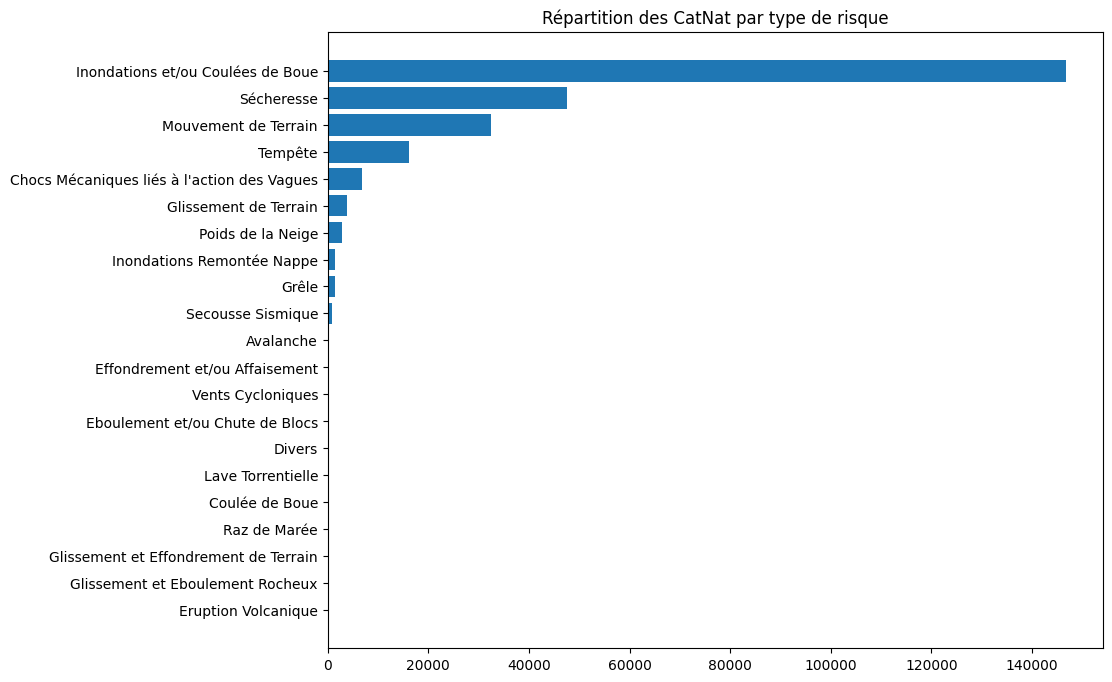

In [7]:
a = df["lib_risque_jo"].value_counts(ascending = True).reset_index(name='count')

plt.figure(figsize = (10,8))
plt.barh(a["lib_risque_jo"], a["count"])
plt.title("Répartition des CatNat par type de risque")
plt.xticks()
plt.show()

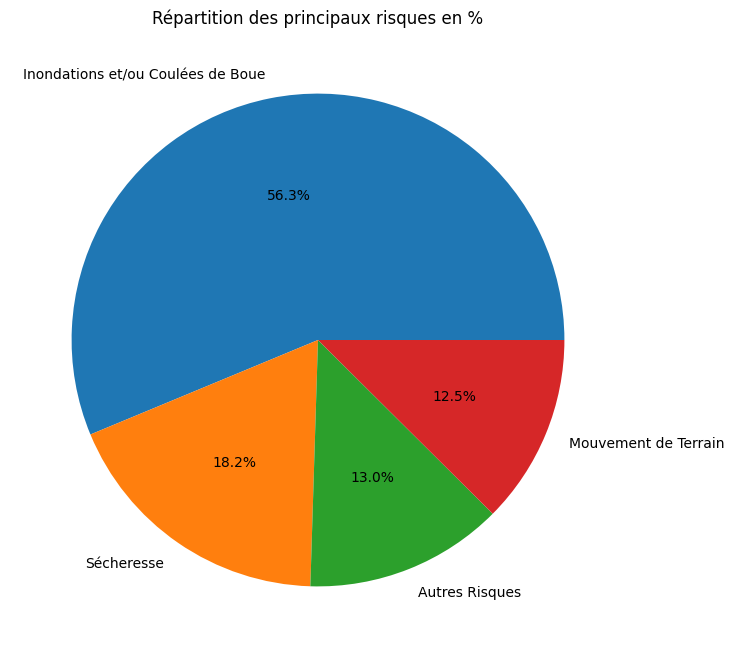

In [8]:
# Nous allons isoler les 3 types de CatNat les plus fréquents
top3 = df['lib_risque_jo'].value_counts().nlargest(3).index

# Créer une nouvelle colonne "Autres Risques" pour regrouper 
df['lib_risque_grouped'] = df['lib_risque_jo'].where(df['lib_risque_jo'].isin(top3),'Autres Risques')

# Recalculer les volumes
counts = df['lib_risque_grouped'].value_counts()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Répartition des principaux risques en %")
plt.show()


- Nous observons que ***Inondations et/ou Coulées de Boue*** sont le type de CatNat le plus représentatif avec ***56.3 %*** de la totalité des castastrophes naturelles reconnues de 1982 à 2025, suivi de la ***Sécheresse*** et des ***Mouvements de Terrain***.
- Tous les autres types de CatNat regroupés dans la catégorie ***Autres Risques*** ne représentent que 13 % de la totalité des castastrophes naturelles.

#### Visualisation des types de CatNat par Département :

In [9]:
df_grouped = df.groupby(["Département","lib_risque_jo"])["lib_risque_jo"].count().reset_index(name = "Total")
df_grouped.head()

,Département,lib_risque_jo,Total
0,01,Glissement de Terrain,3
1,01,Grêle,7
2,01,Inondations Remontée Nappe,1
3,01,Inondations et/ou Coulées de Boue,776
4,01,Mouvement de Terrain,51


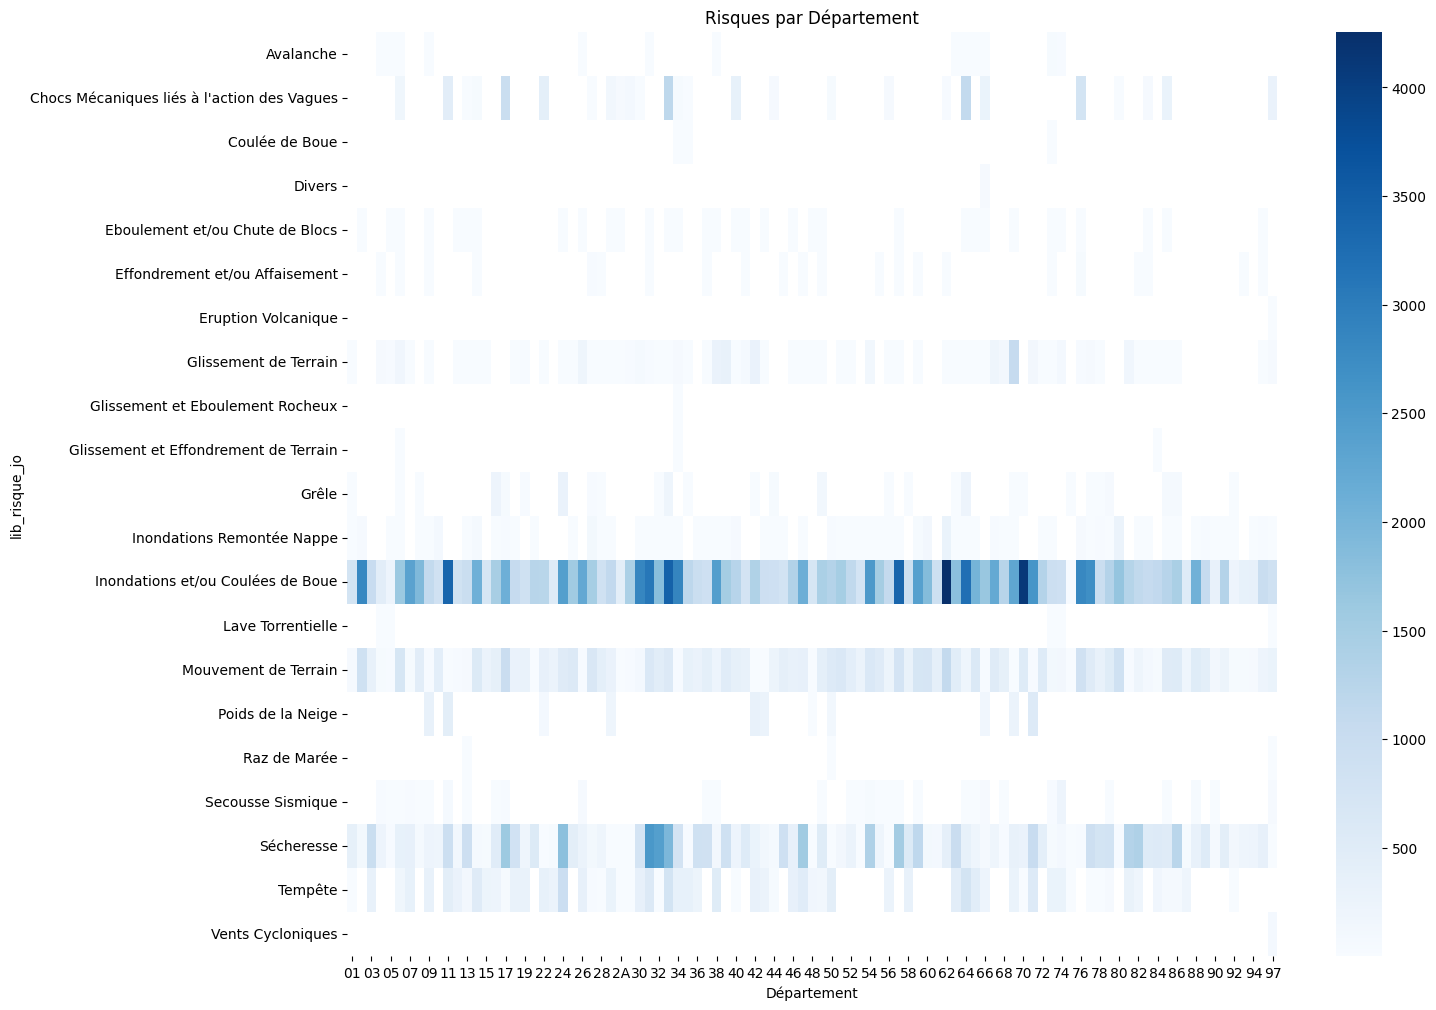

In [10]:
pivot = df_grouped.pivot_table(
    index="lib_risque_jo",
    columns="Département",
    values="Total"
)

plt.figure(figsize=(15, 12))
sns.heatmap(pivot, cmap="Blues")
plt.title("Risques par Département")
plt.show()

#### Visulisation proportionnelle des 3 types les plus importants par département:

In [11]:
# Ajout d'une colonne "SumDpt" qui va nous donner le nombre de CatNat / Département

df_grouped["SumDpt"] = df_grouped.groupby("Département")["Total"].transform("sum")

# Pour isoler nos 3 types les plus importants par département, nous allons d'abord utiliser la méthode rank sur notre df_grouped

df_grouped["rank"] = (df_grouped.groupby("Département")["Total"].rank(method="first", ascending=False))

# Utilisation de la méthode where pour conserver les valeurs de rank <= 3 et classer les autres dans la catégorie "Autre Risque"

df_grouped["lib_risque_grouped"] = (df_grouped["lib_risque_jo"].where(df_grouped["rank"] <= 3, "Autre Risque"))

df_grouped.head(2)


,Département,lib_risque_jo,Total,SumDpt,rank,lib_risque_grouped
0,01,Glissement de Terrain,3,1228,6.0,Autre Risque
1,01,Grêle,7,1228,5.0,Autre Risque


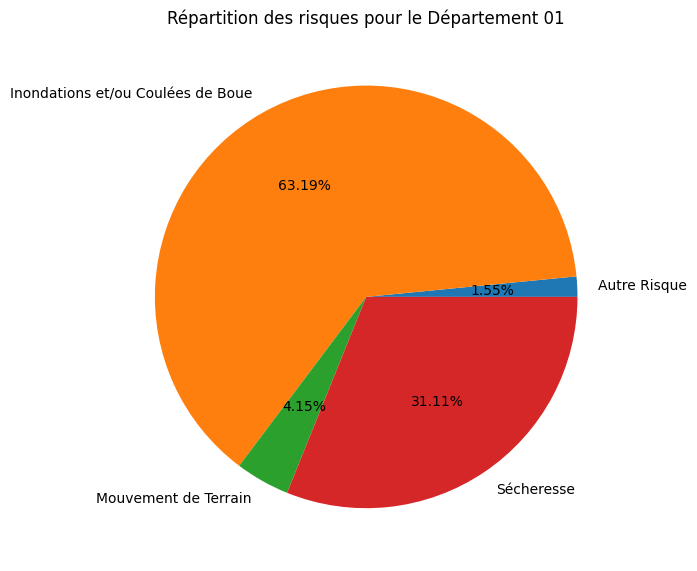

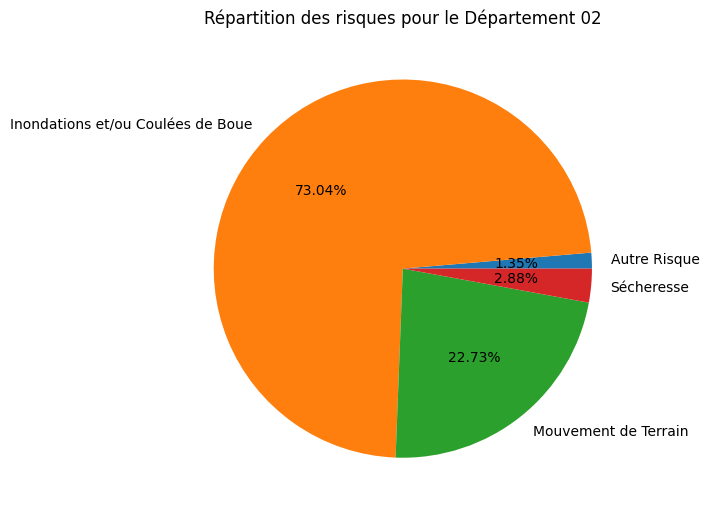

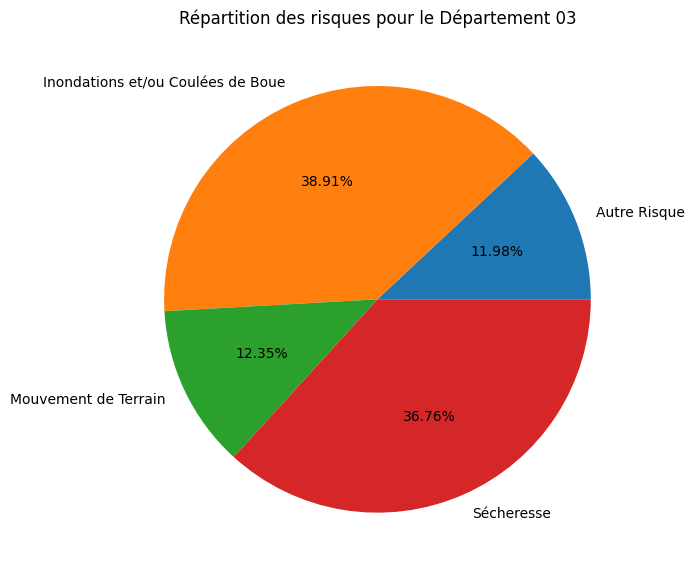

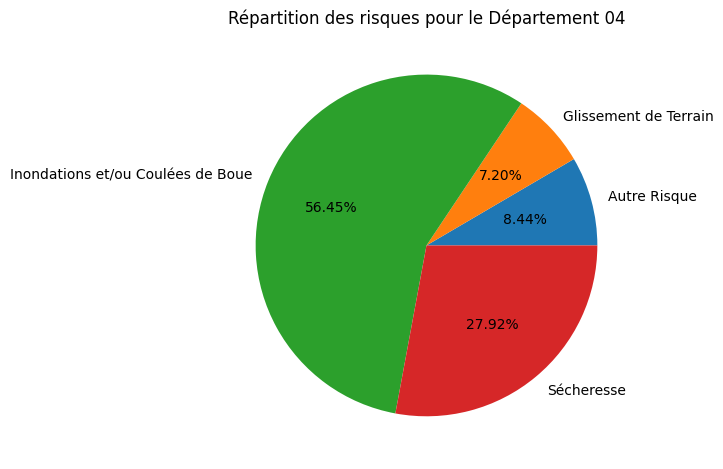

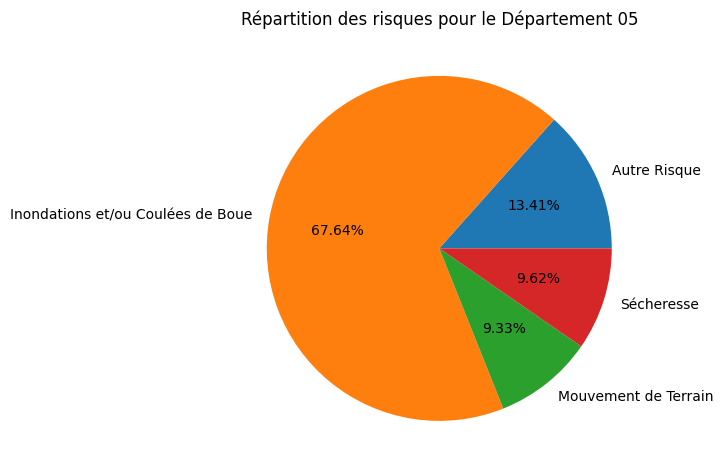

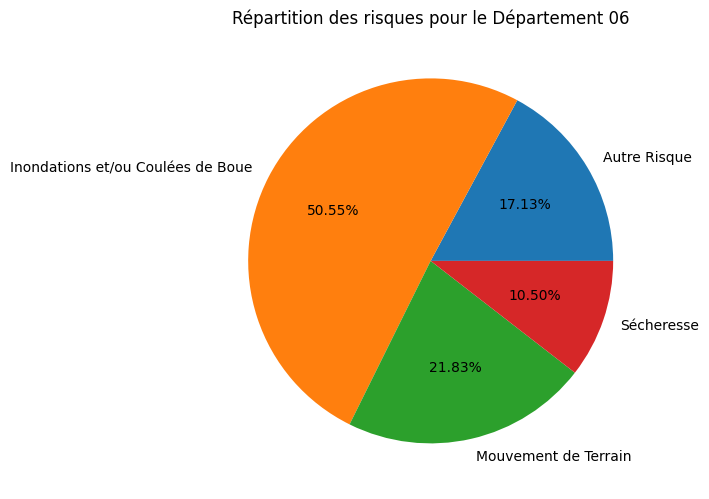

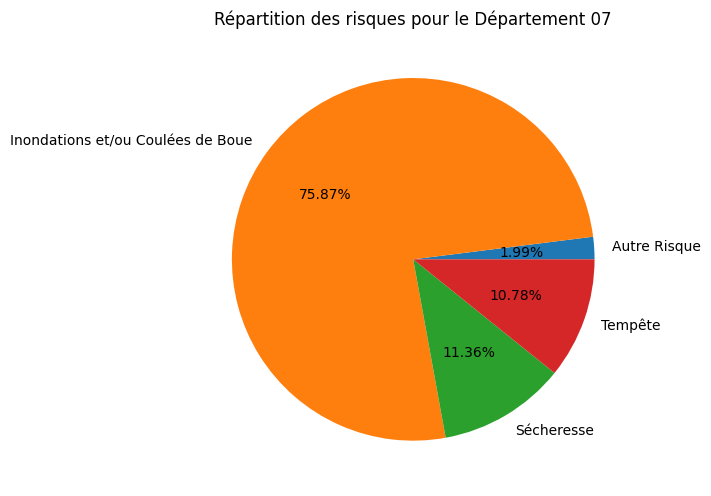

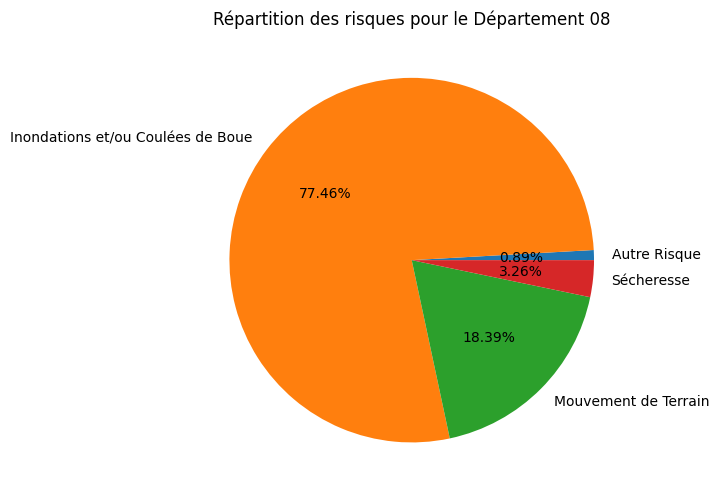

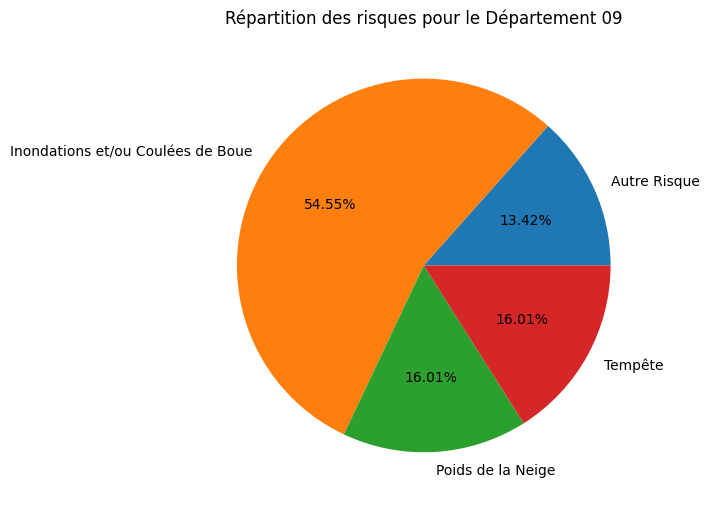

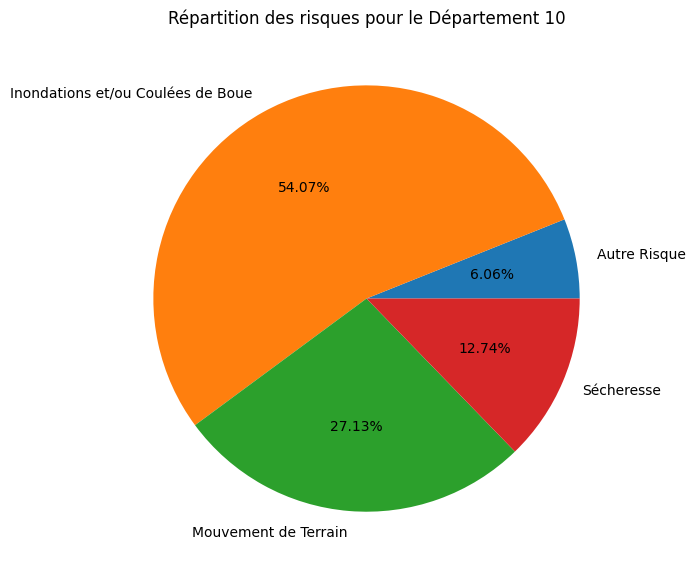

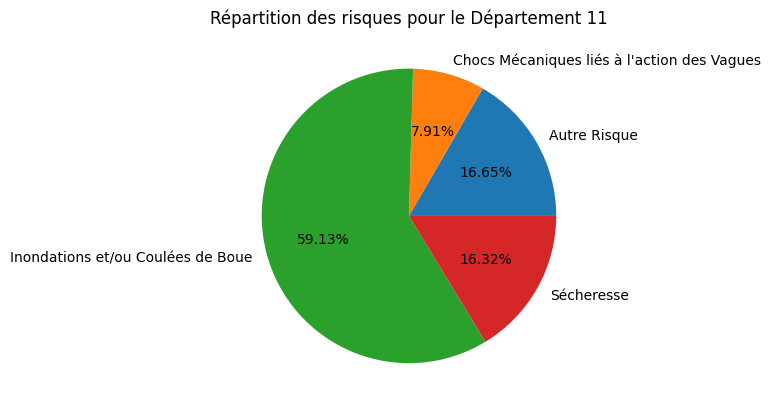

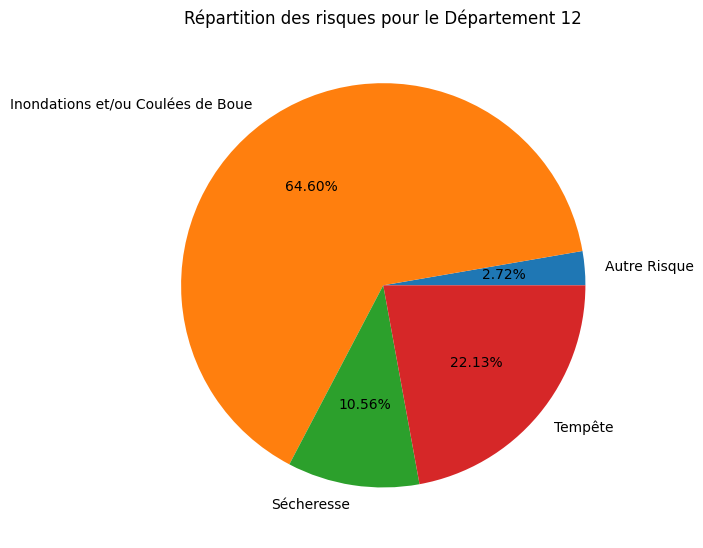

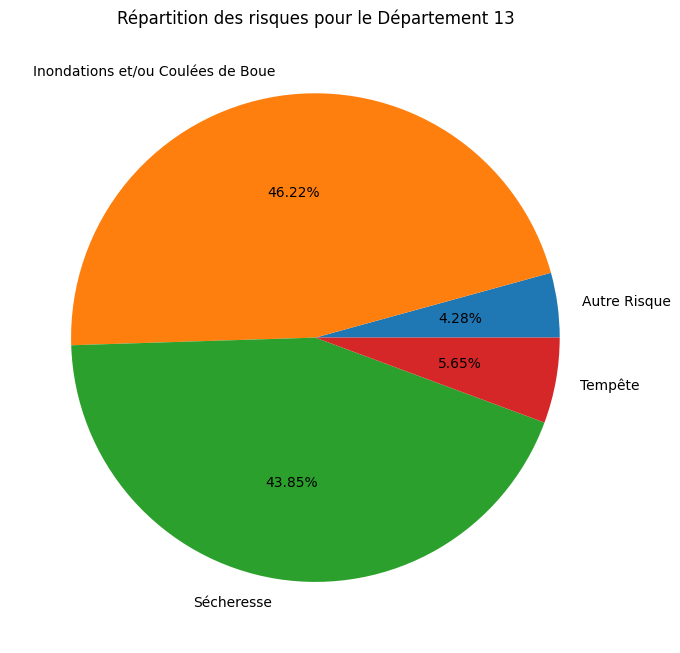

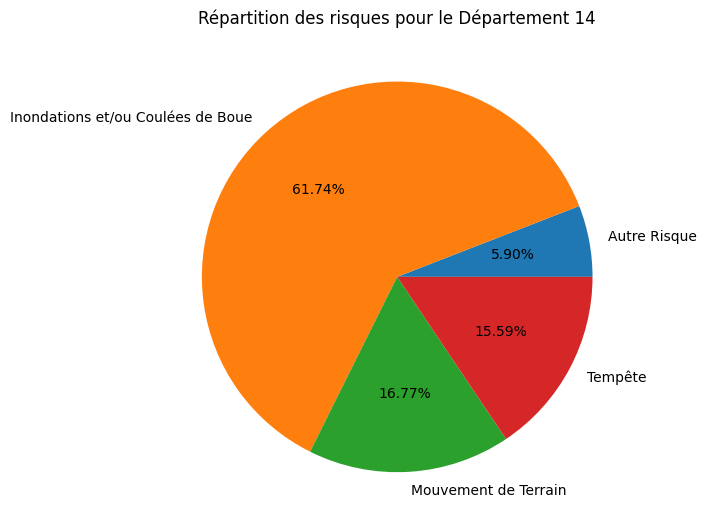

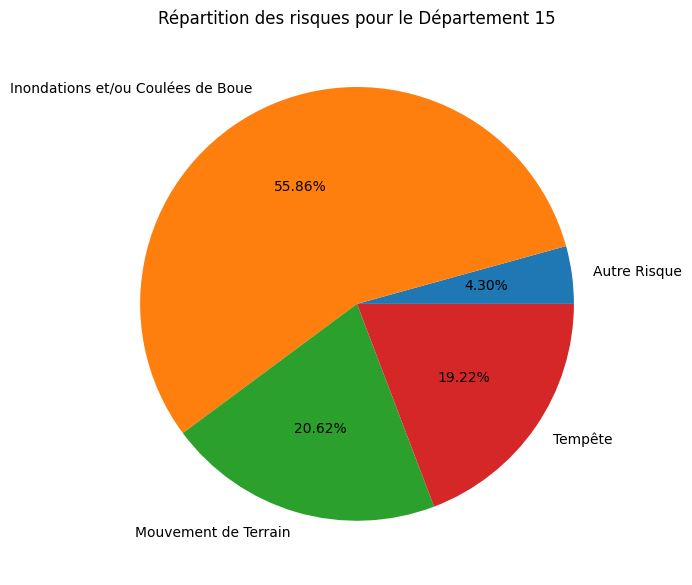

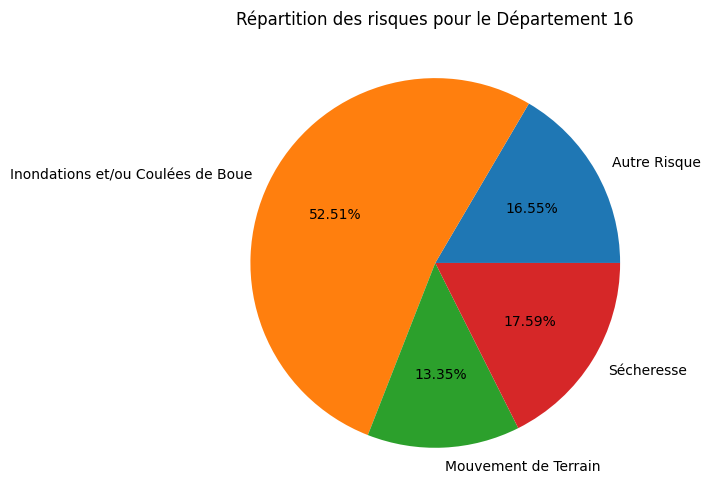

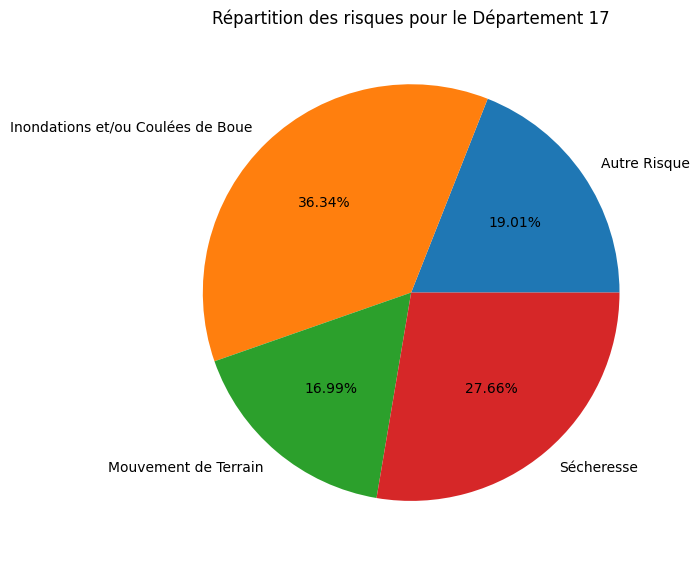

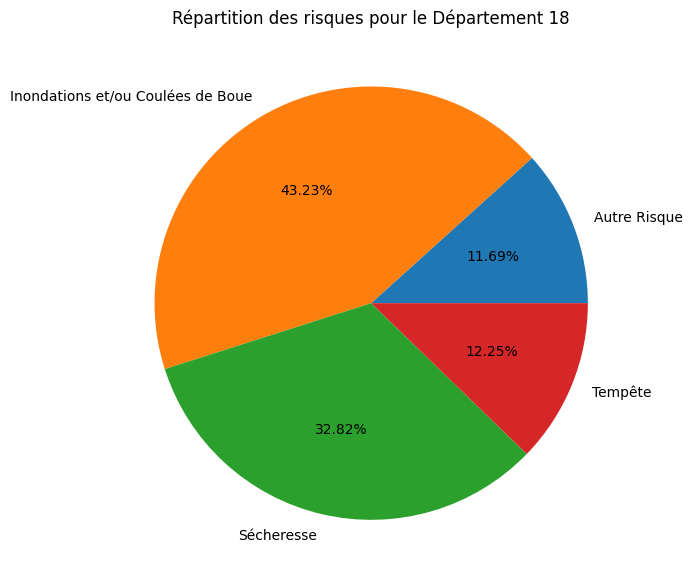

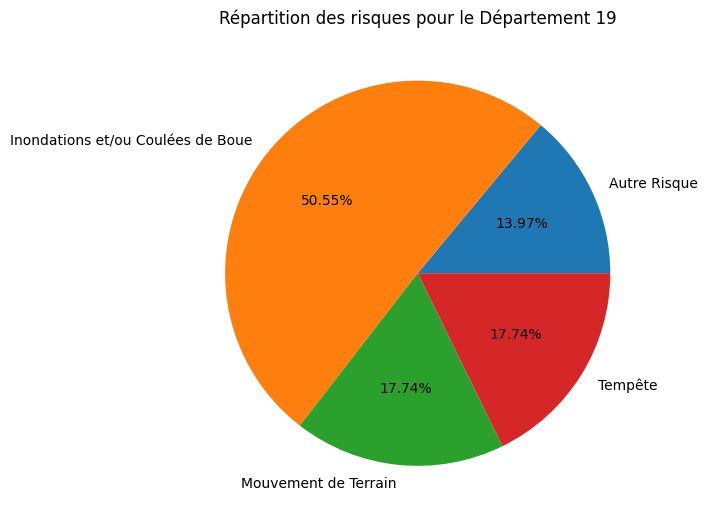

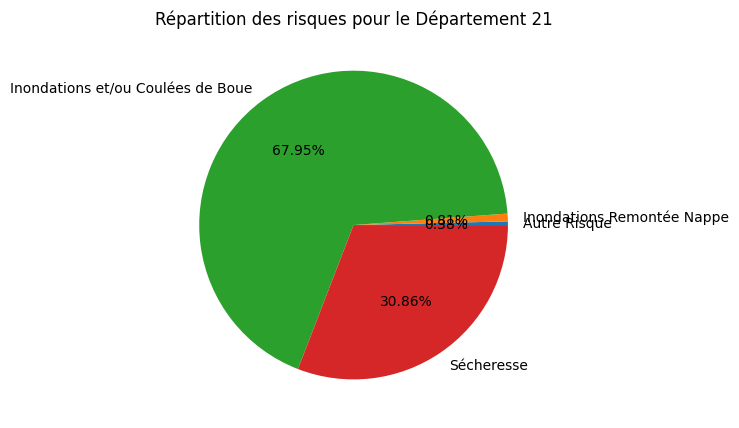

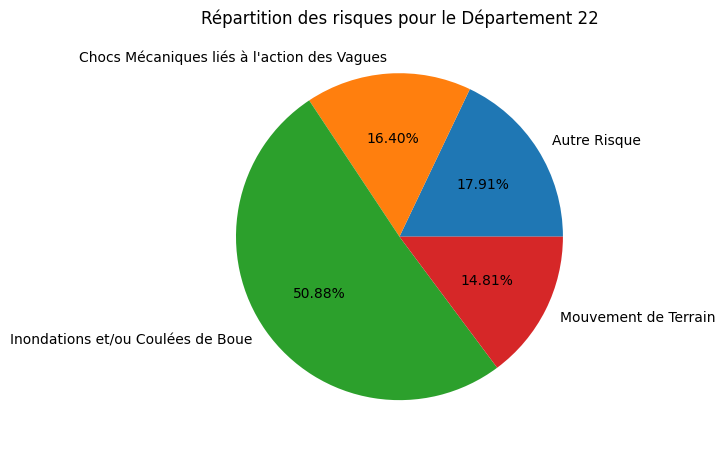

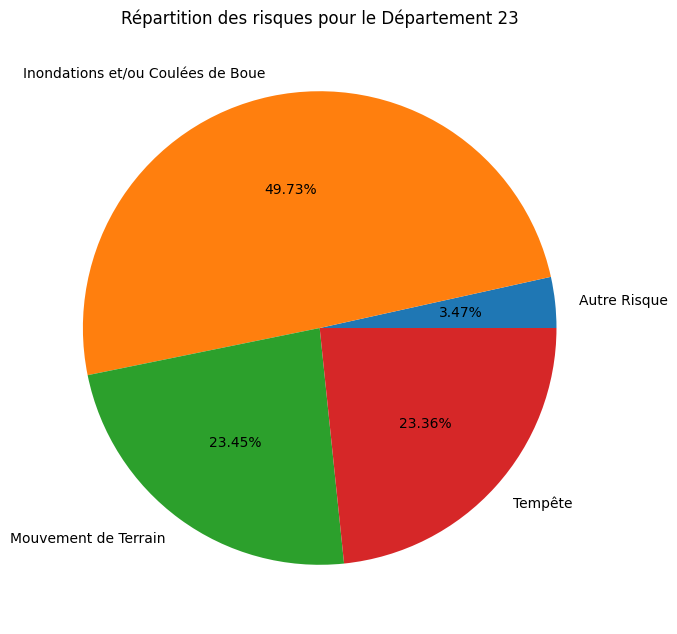

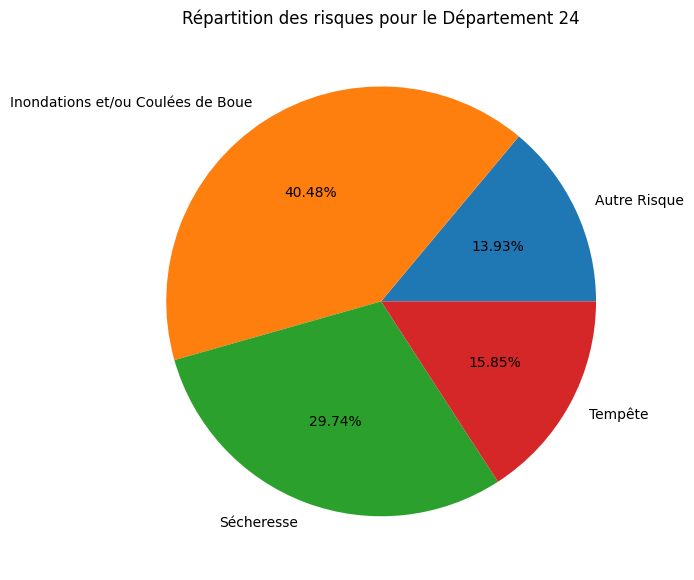

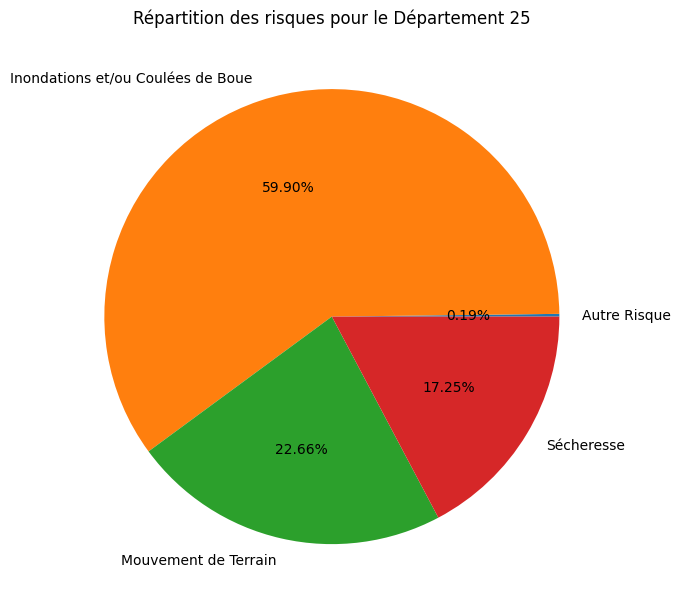

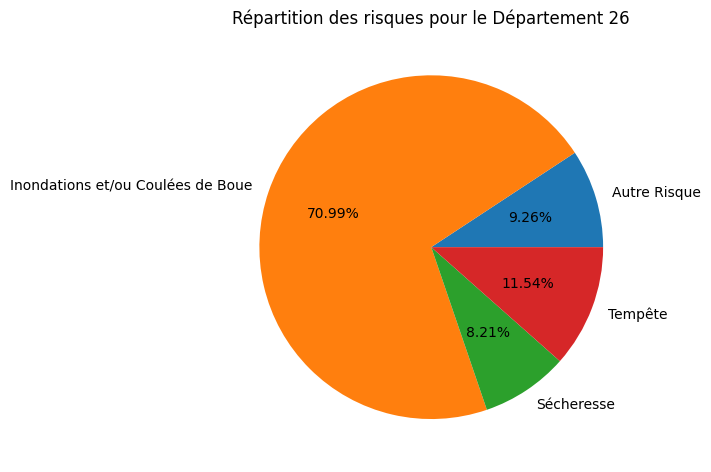

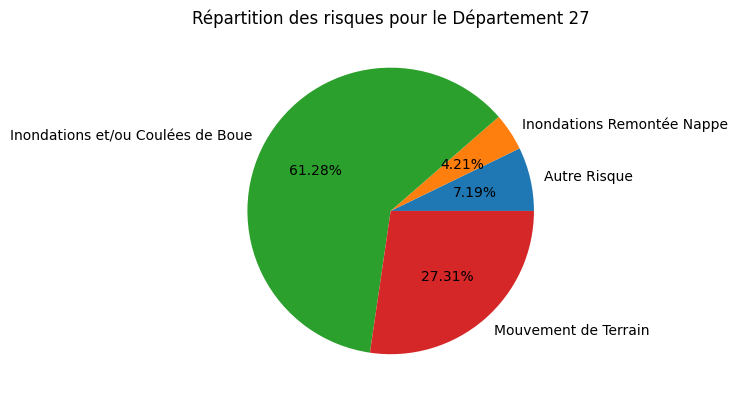

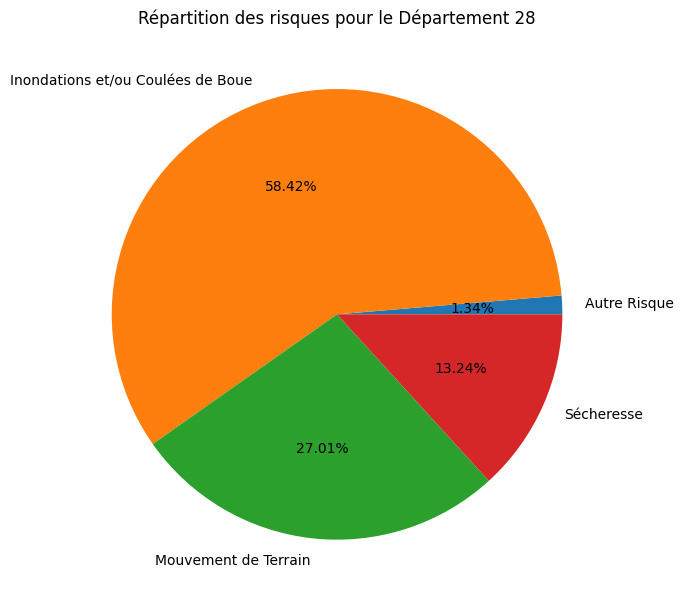

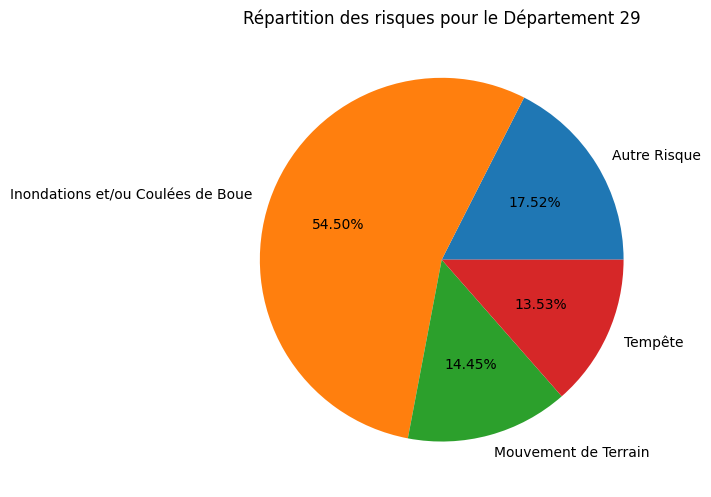

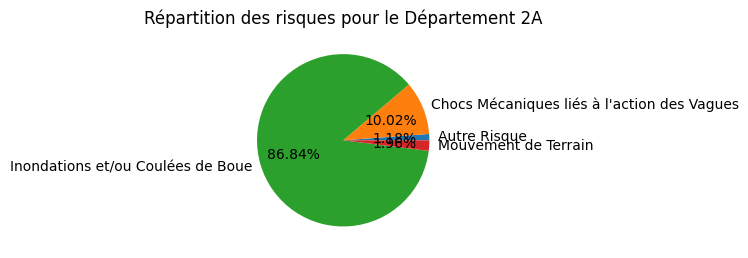

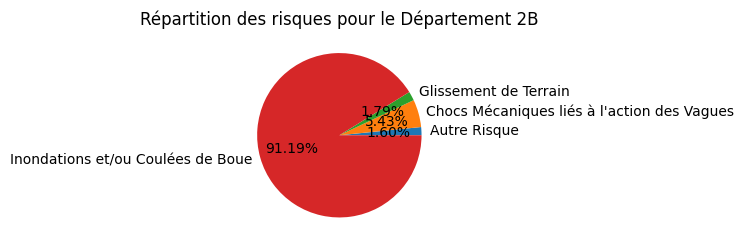

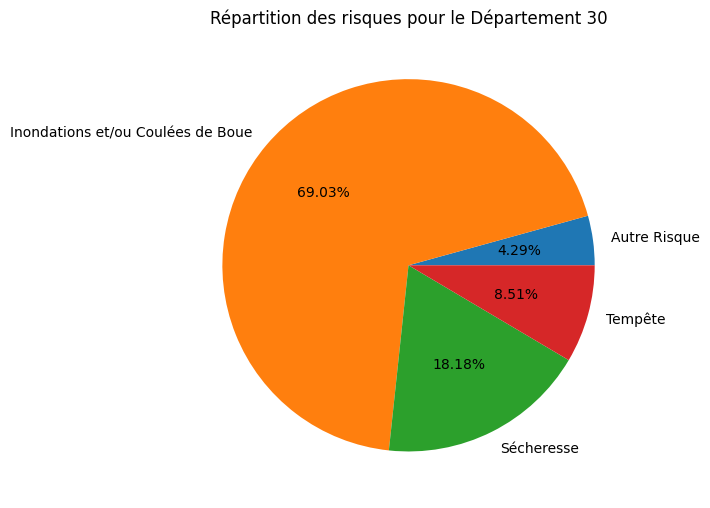

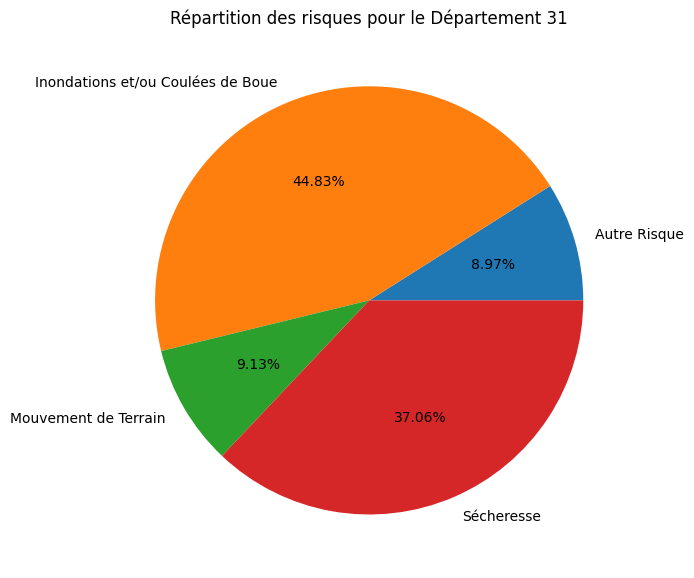

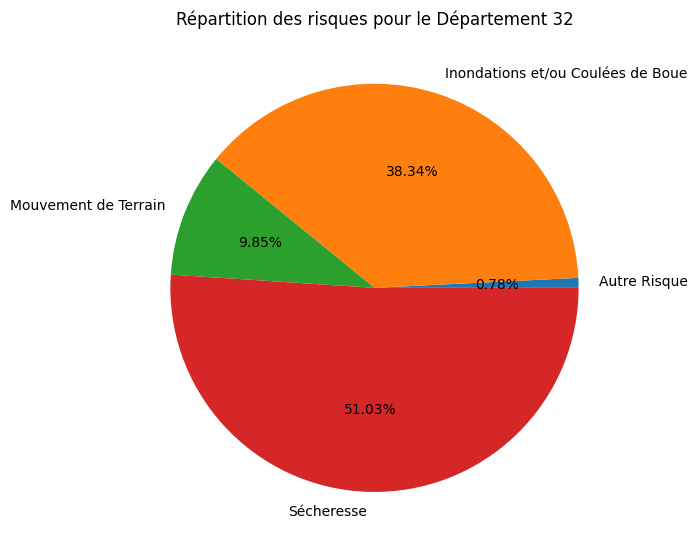

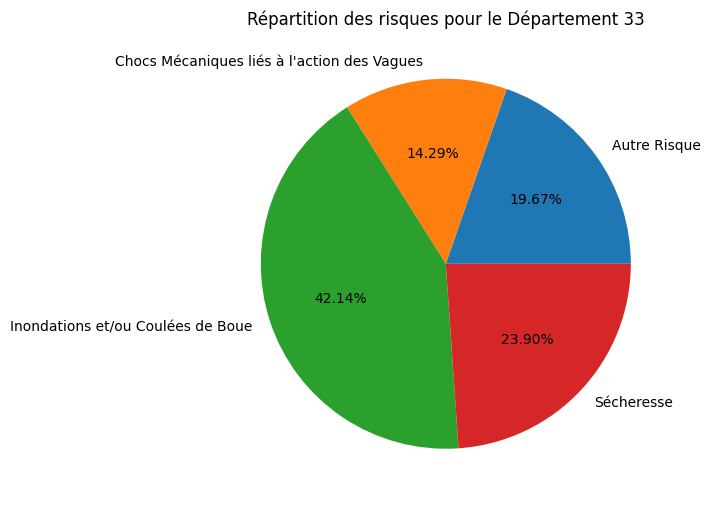

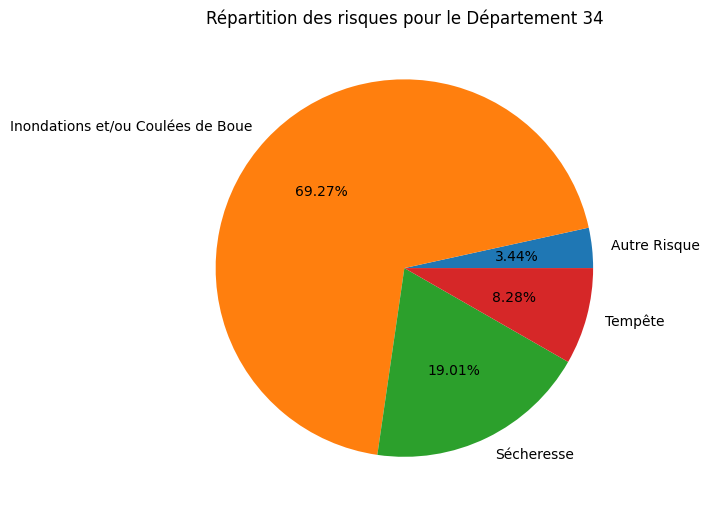

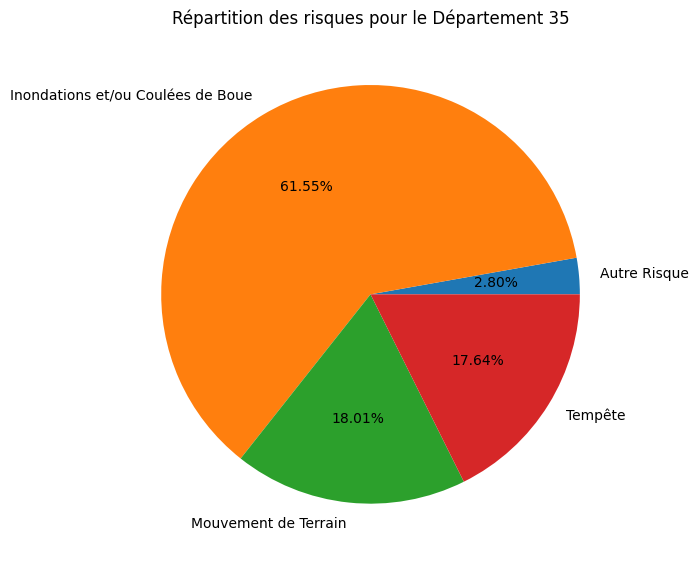

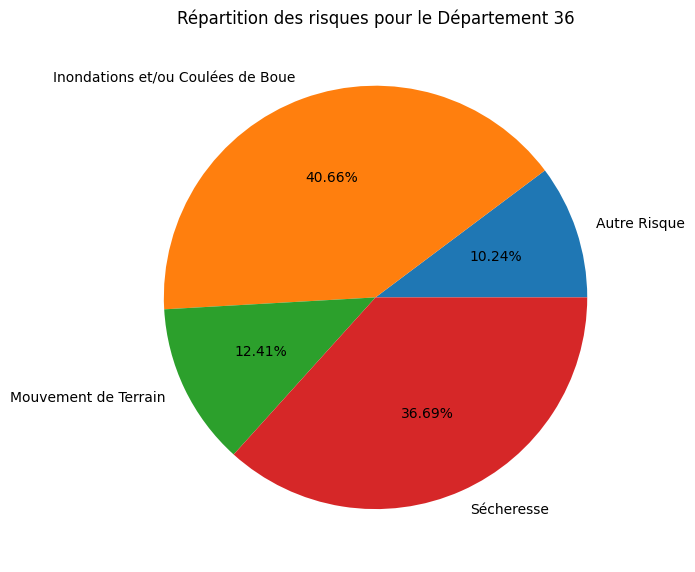

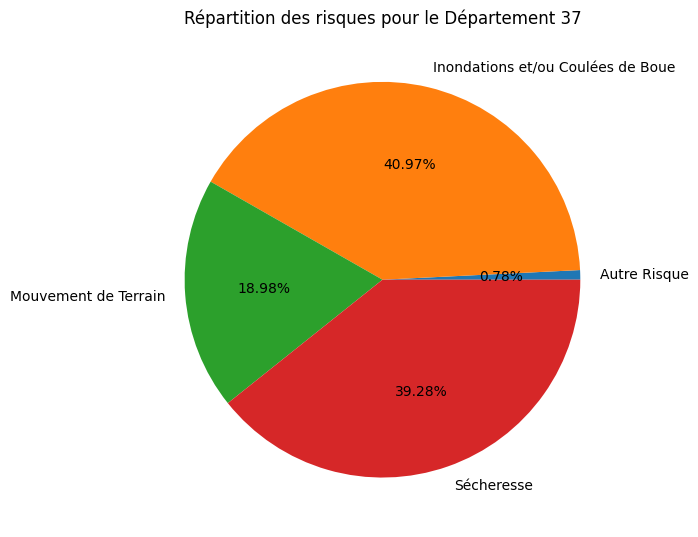

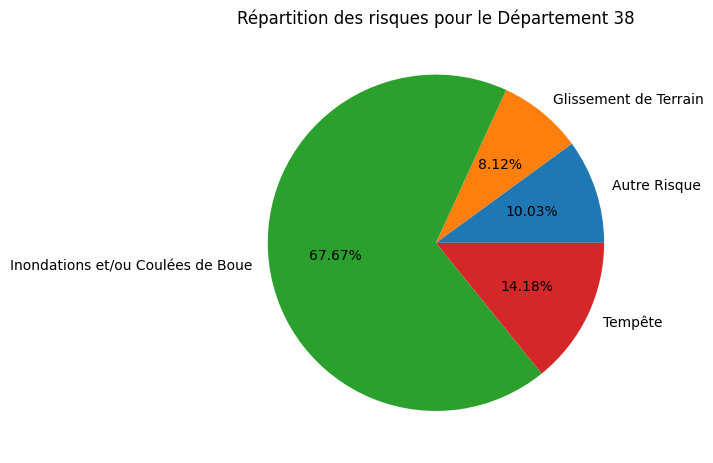

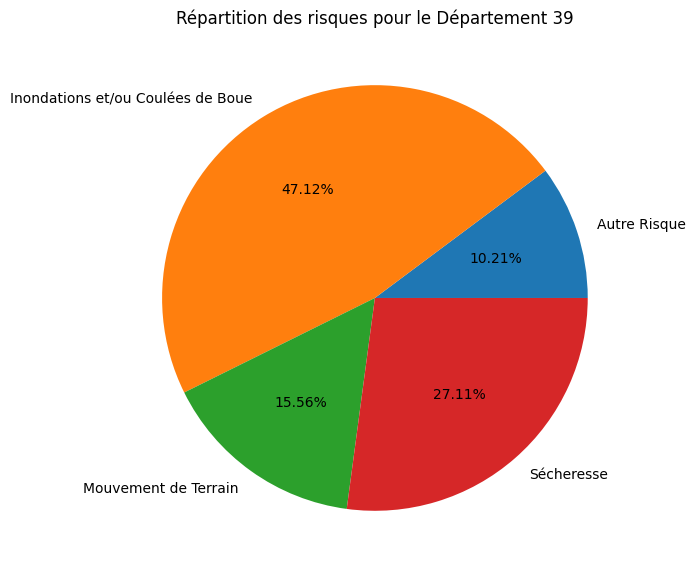

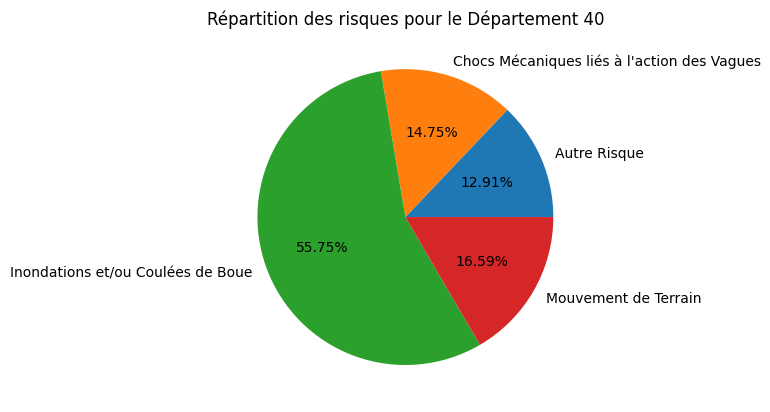

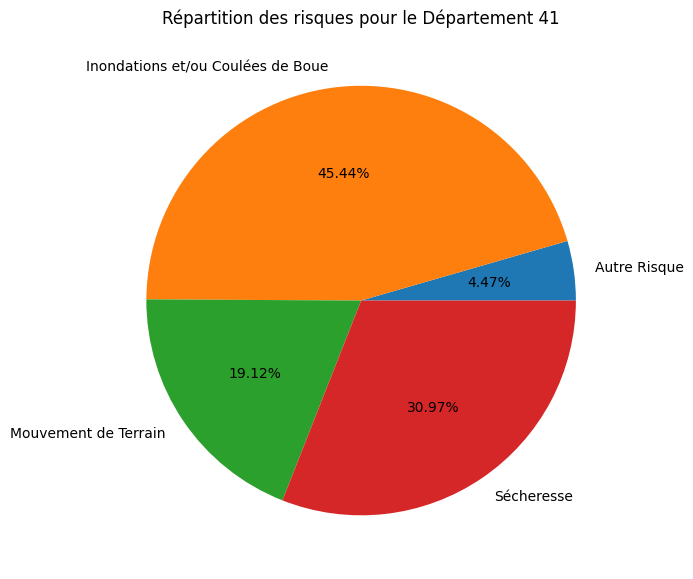

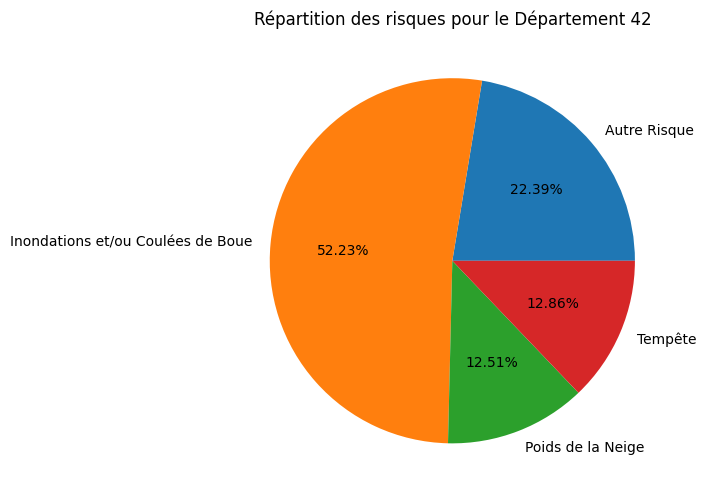

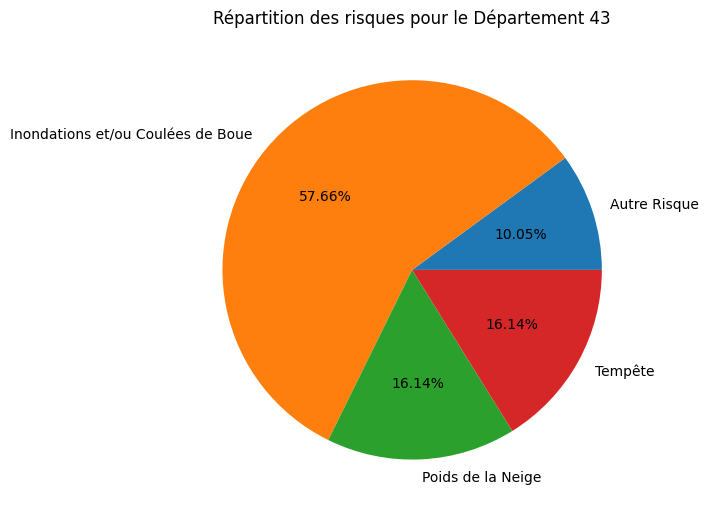

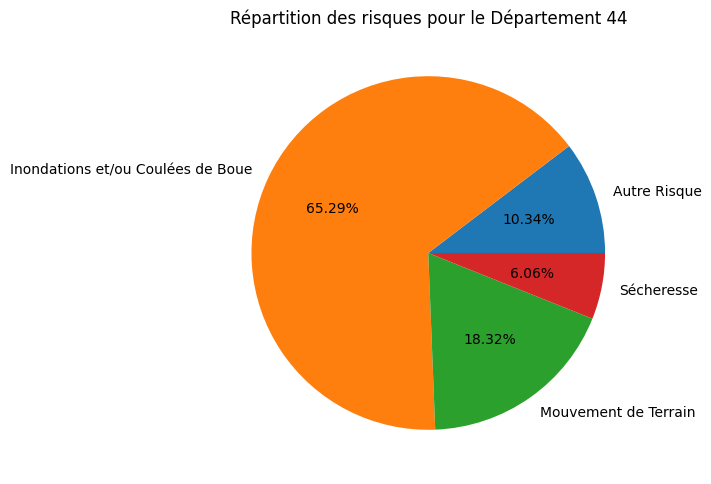

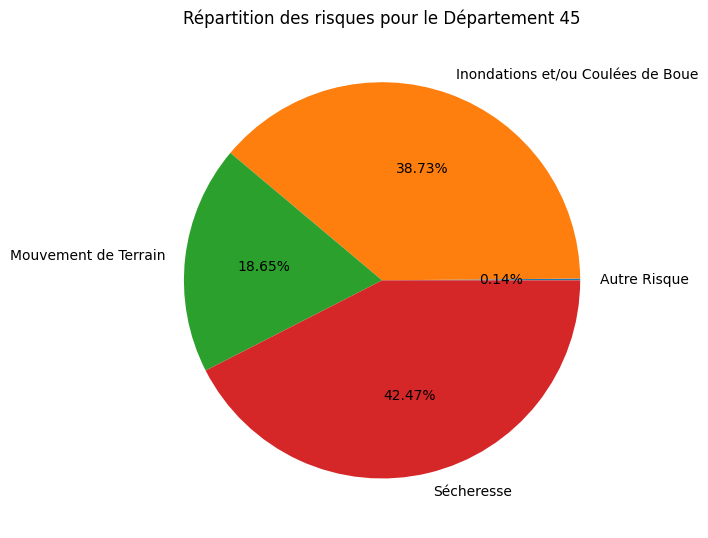

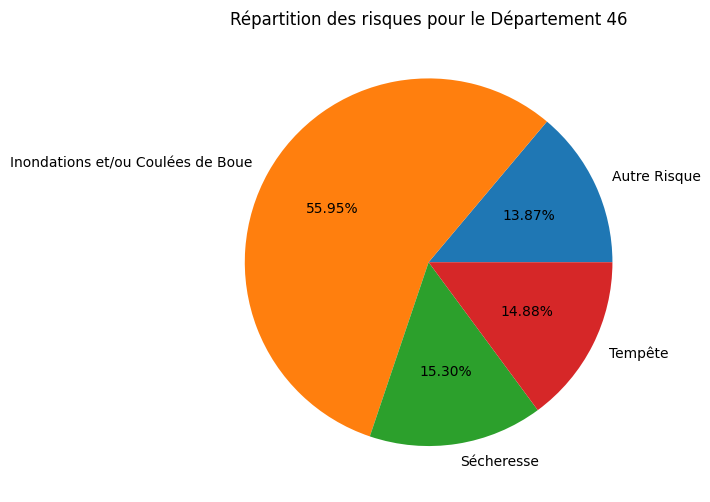

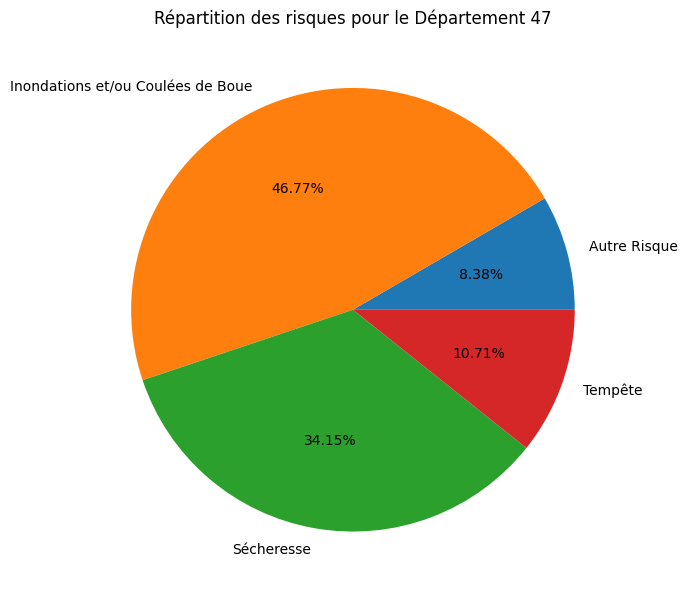

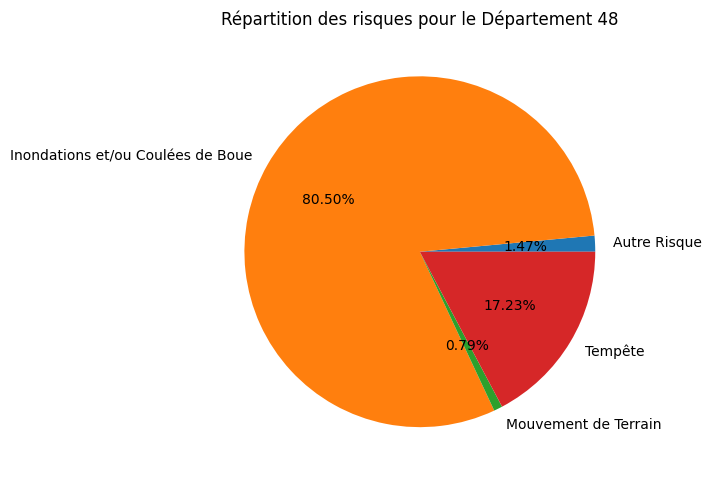

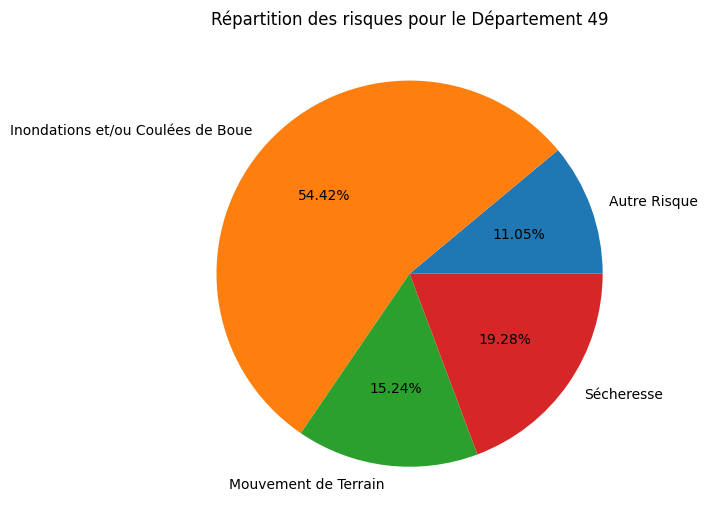

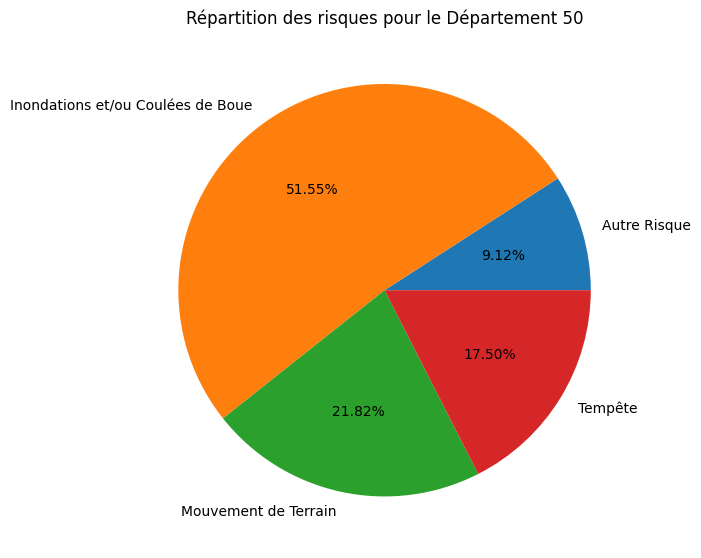

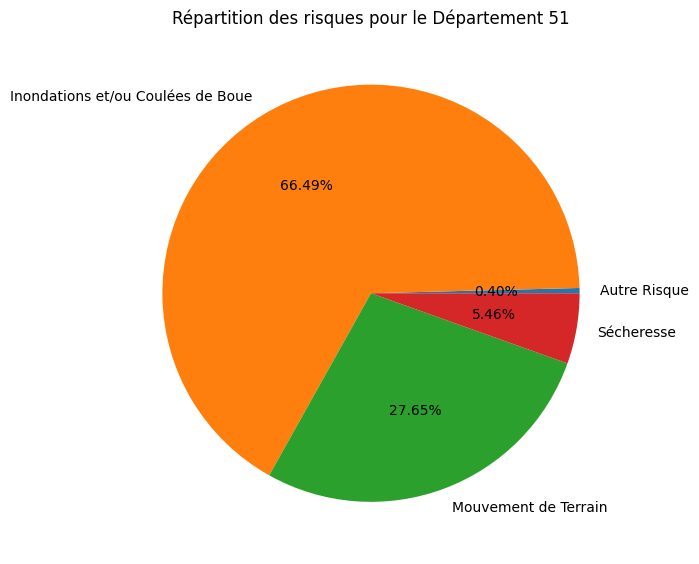

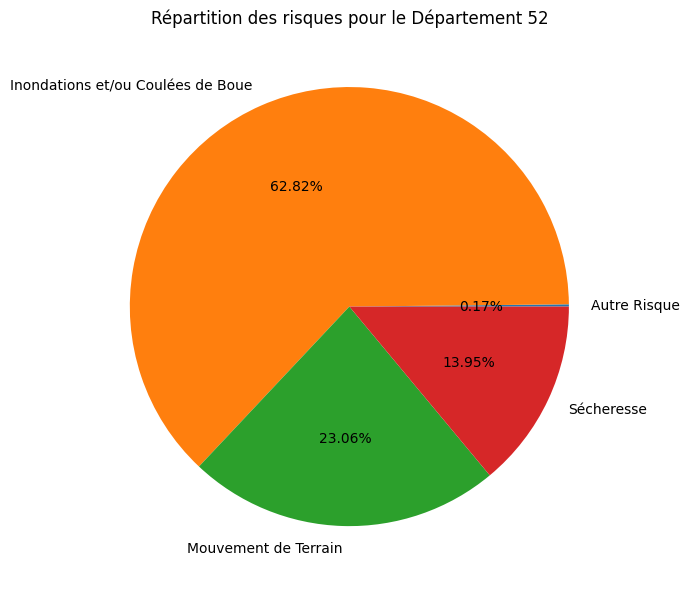

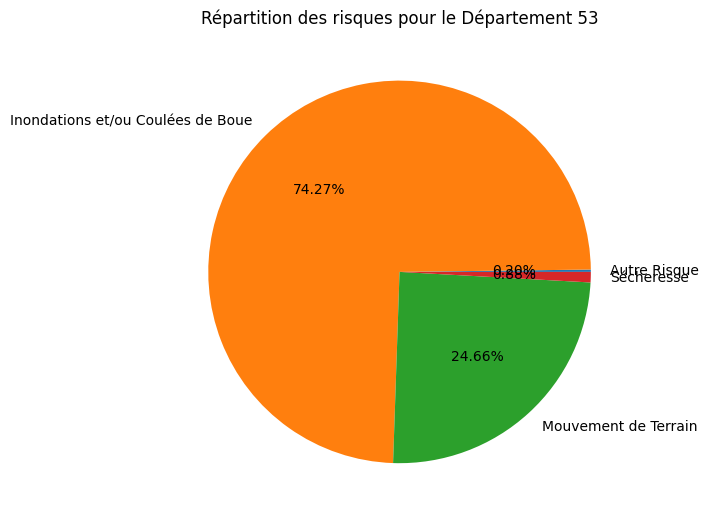

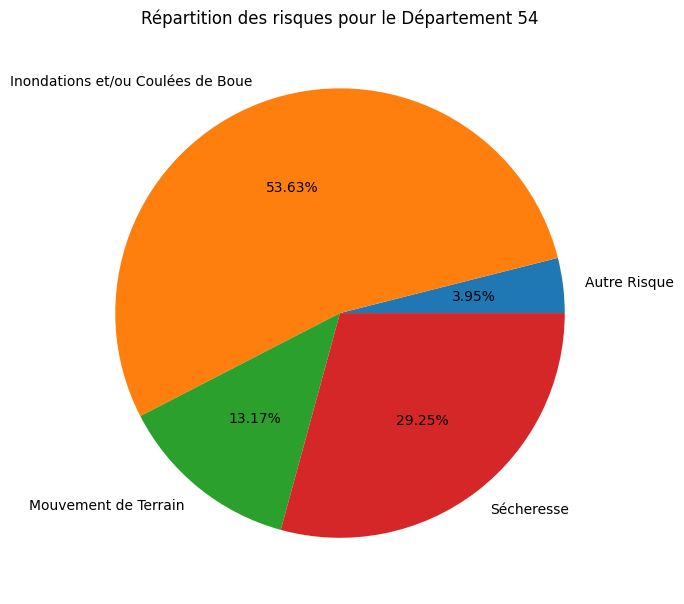

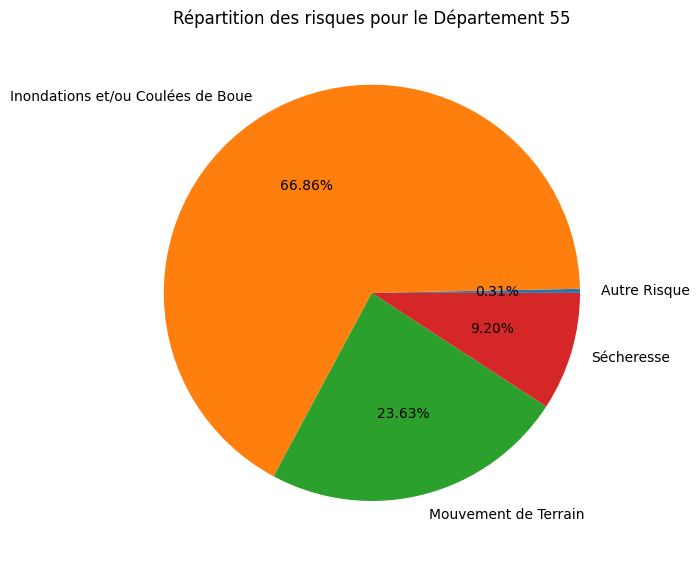

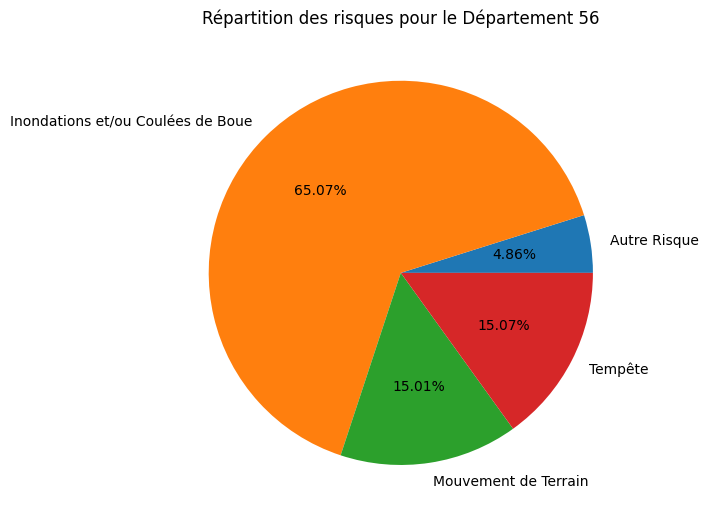

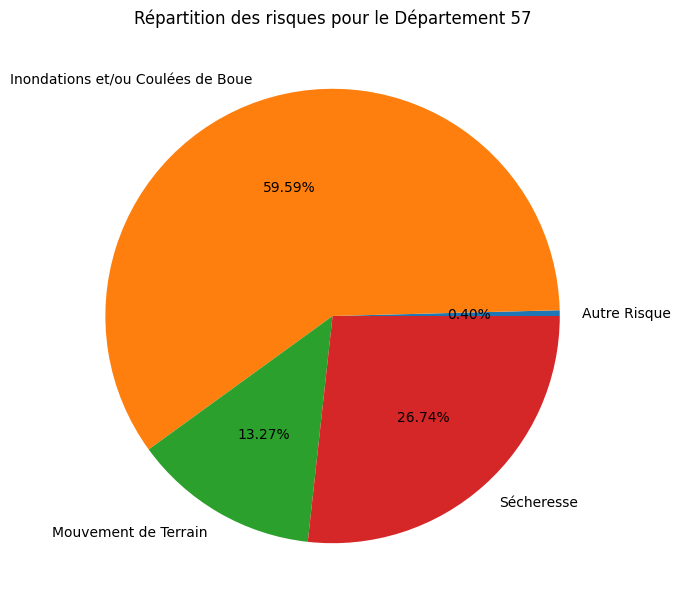

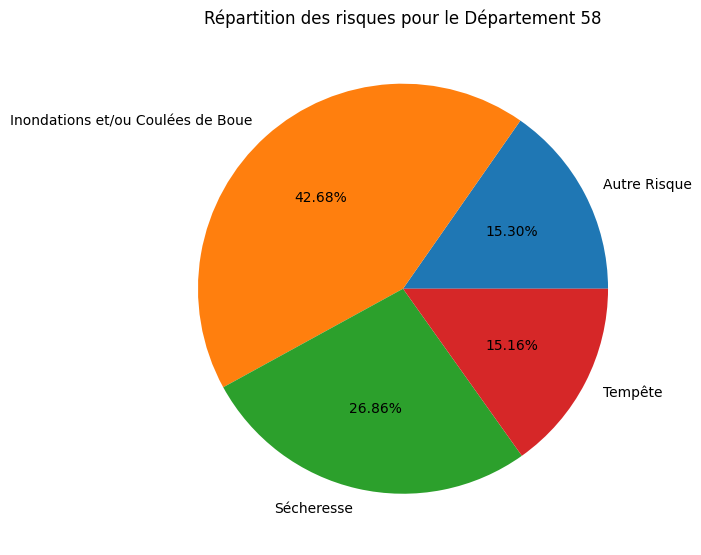

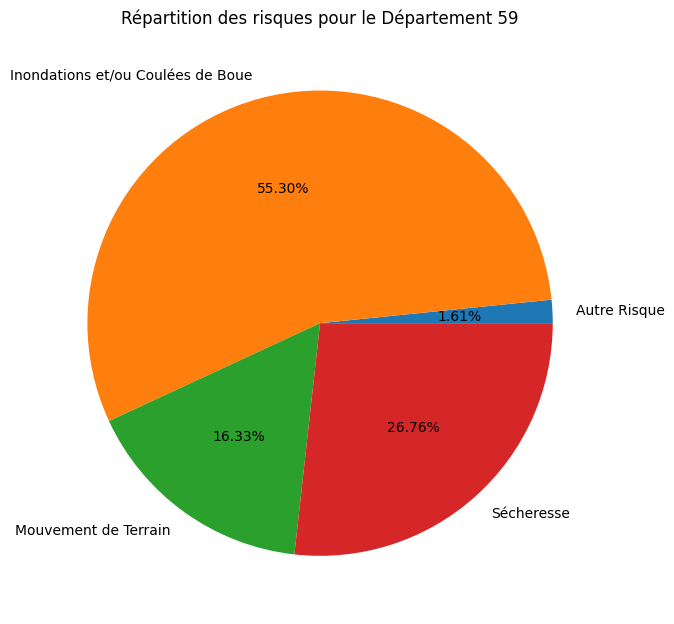

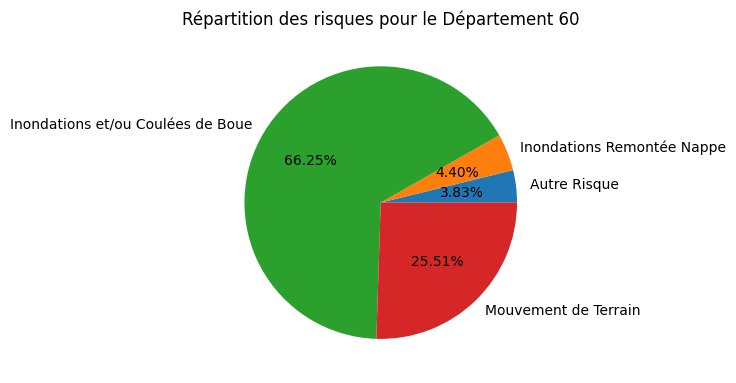

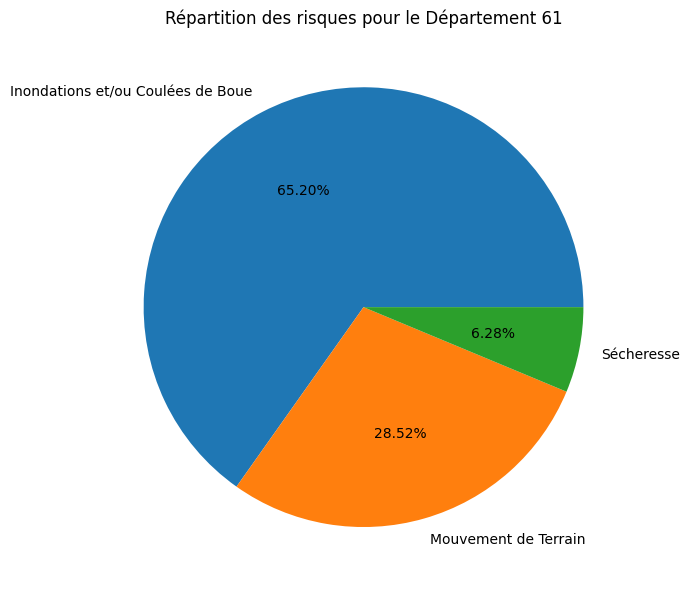

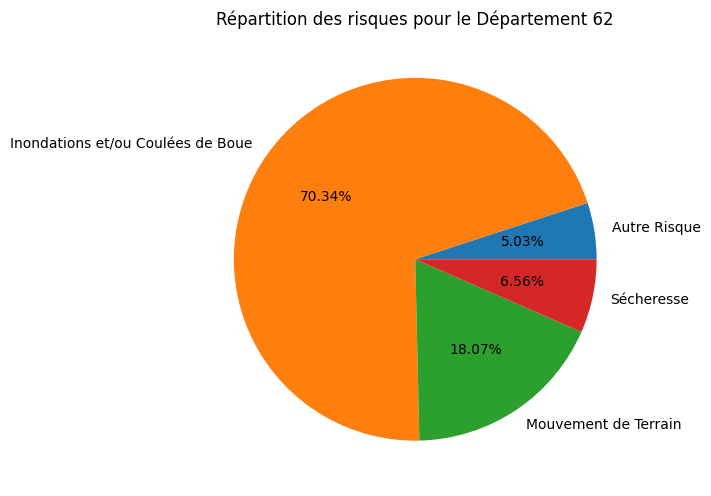

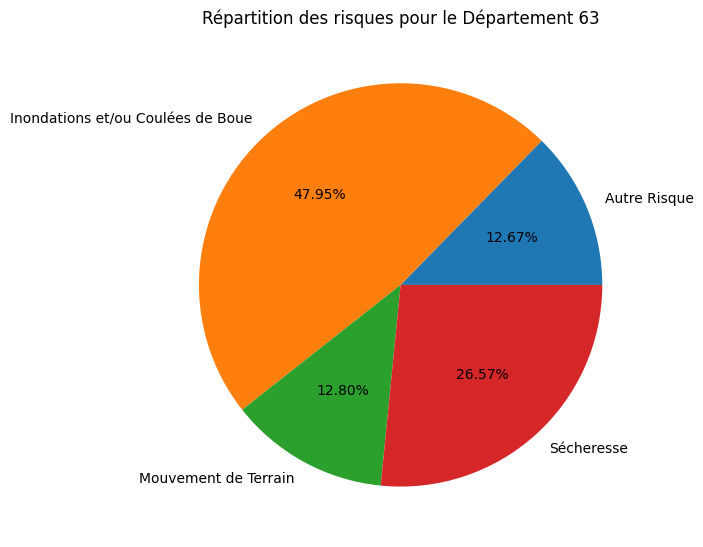

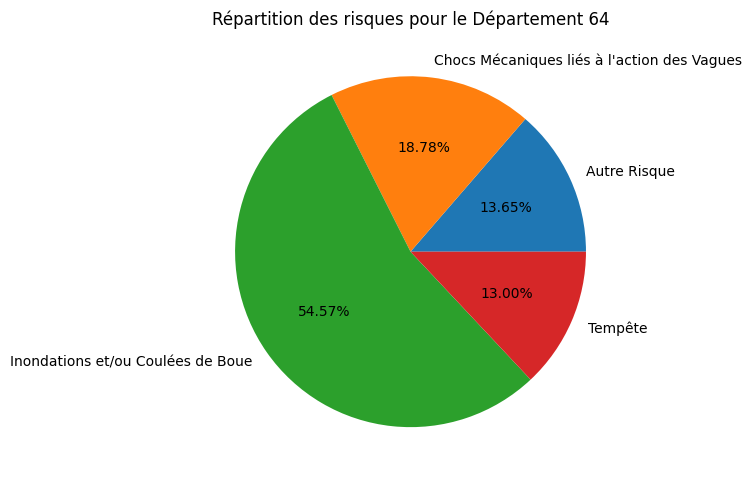

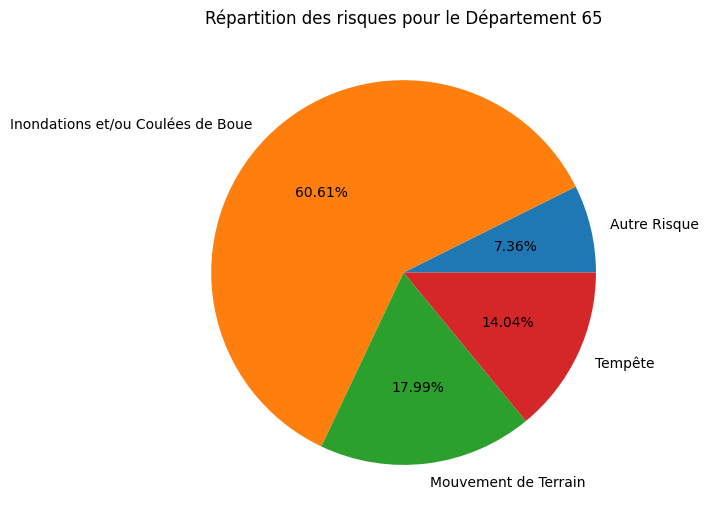

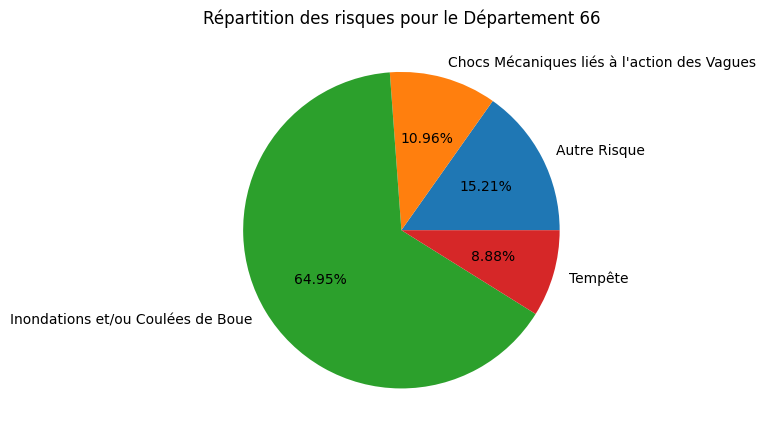

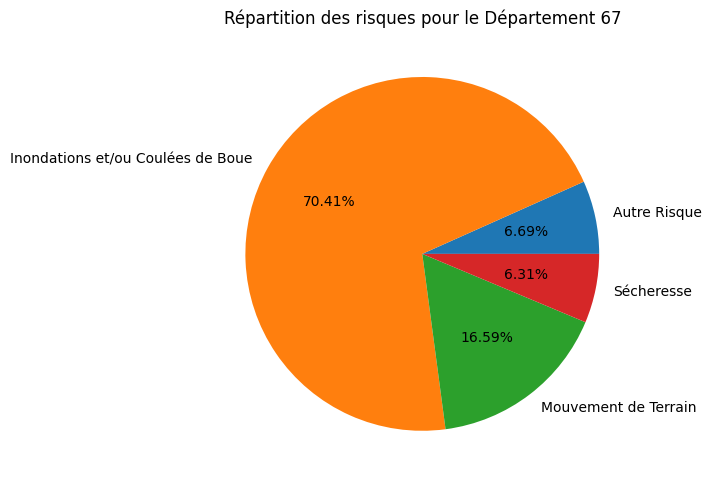

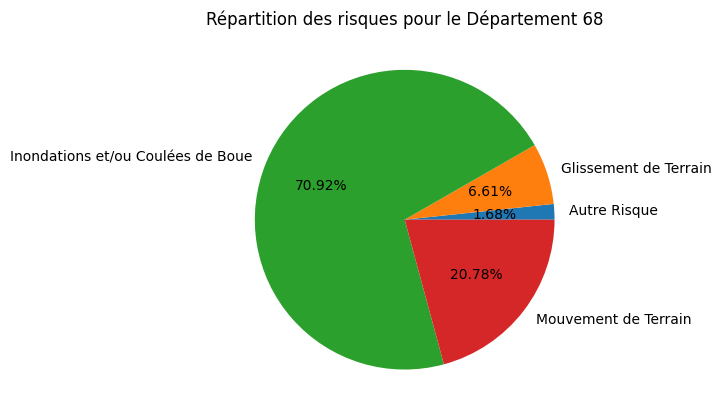

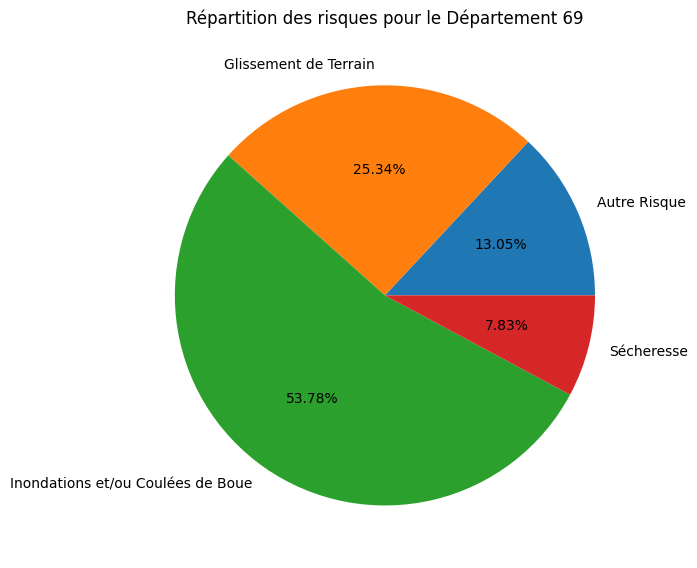

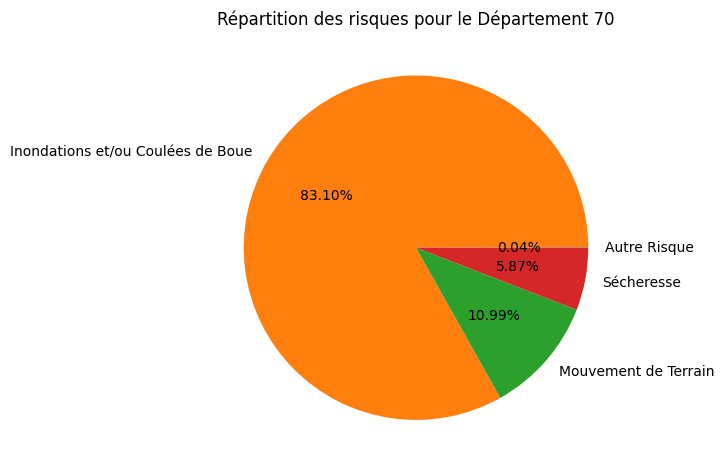

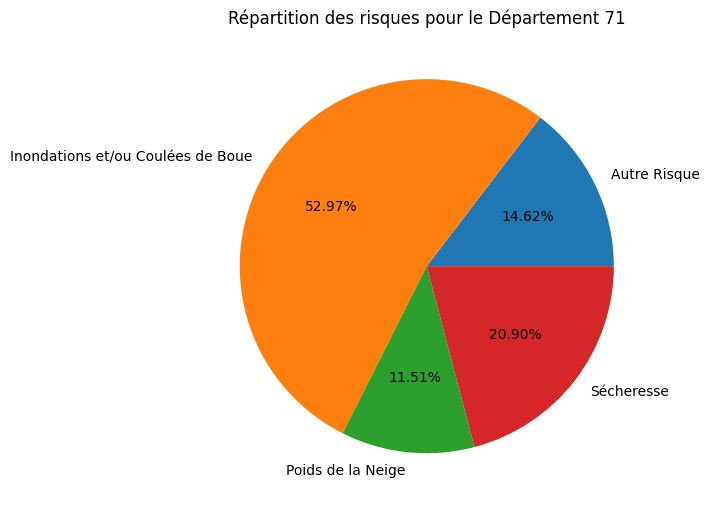

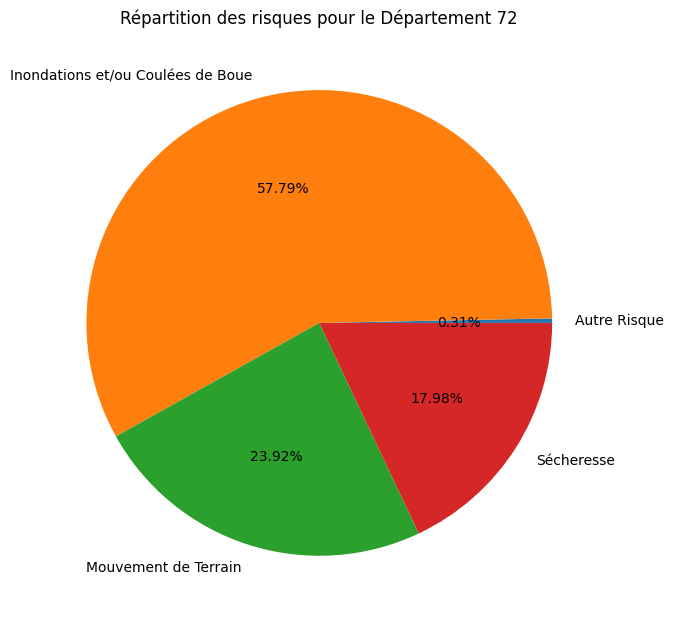

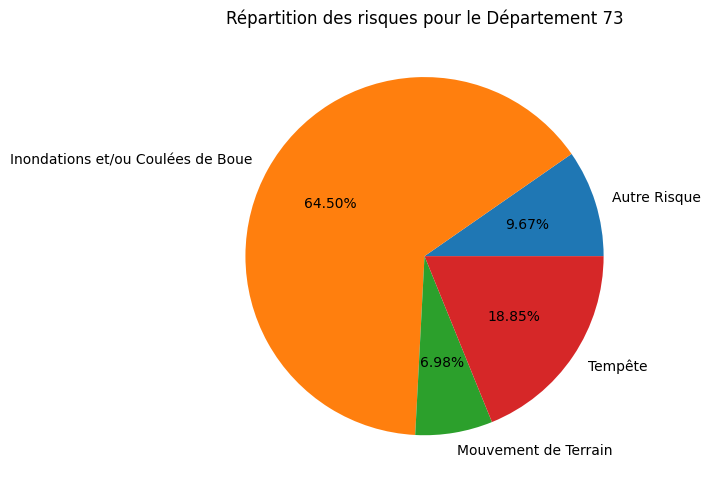

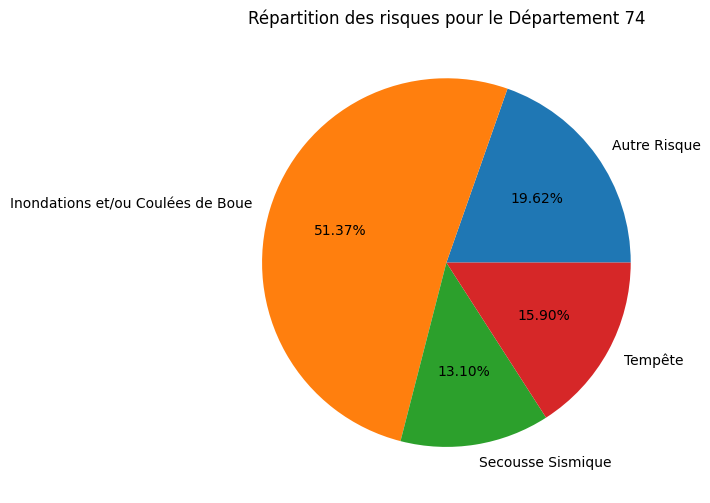

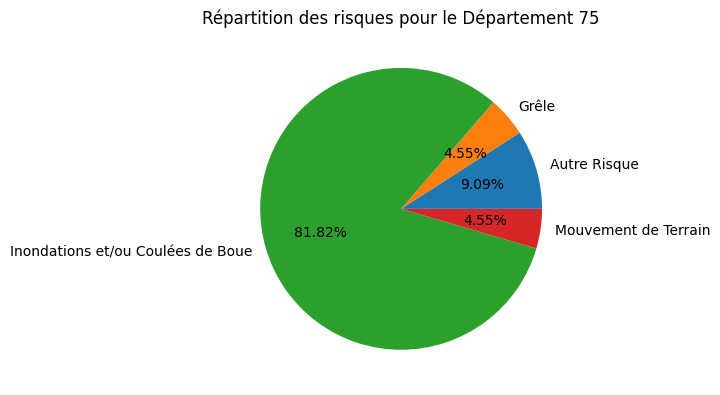

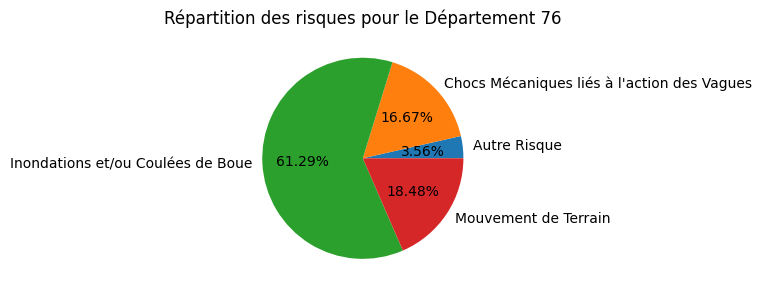

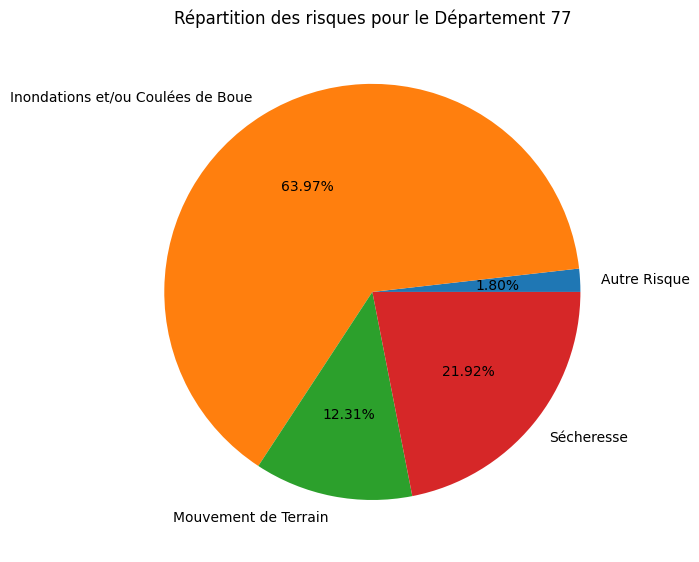

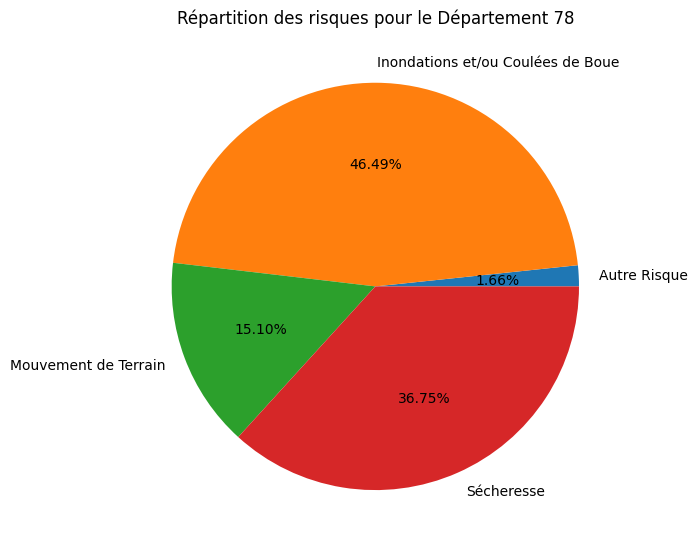

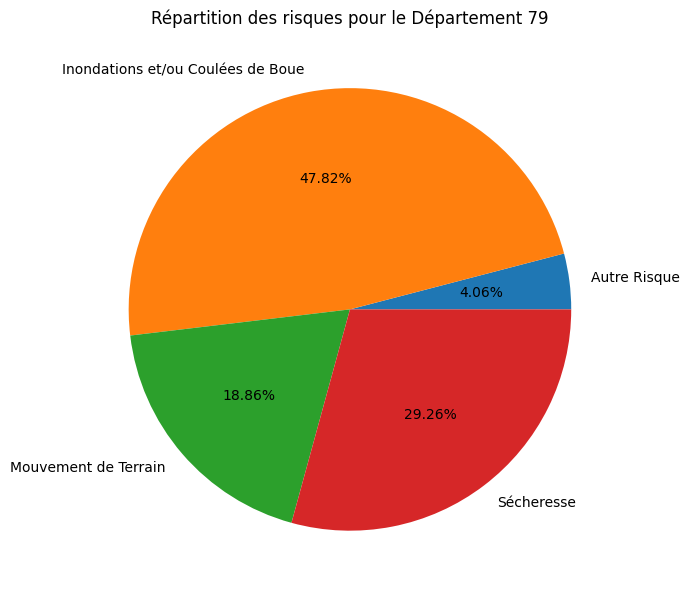

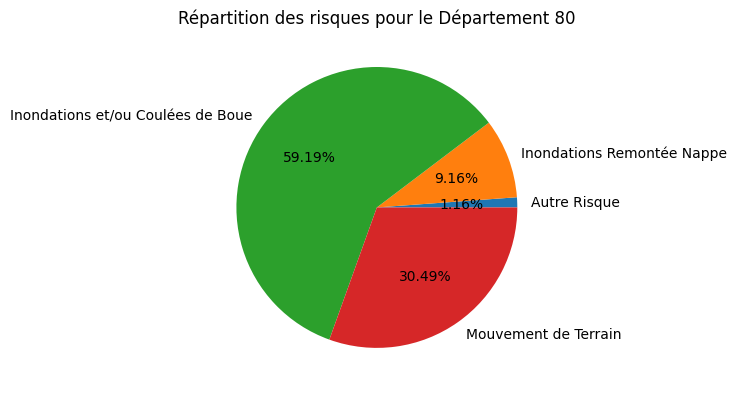

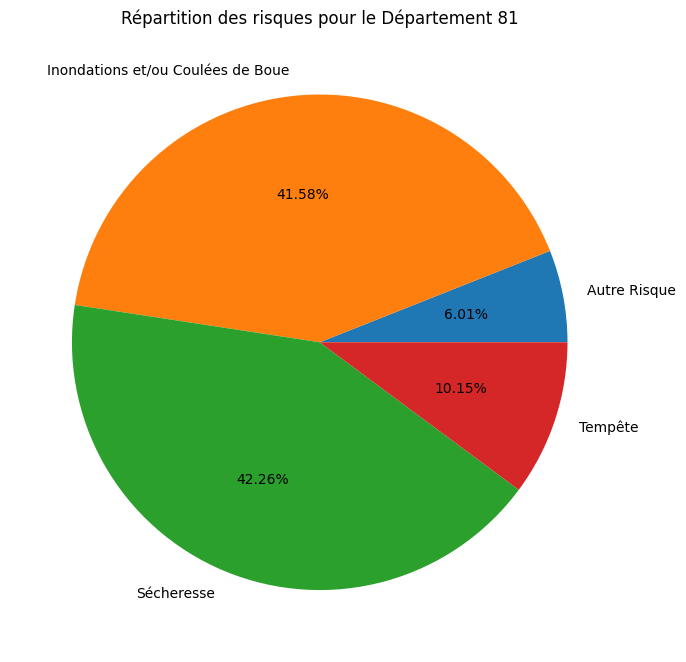

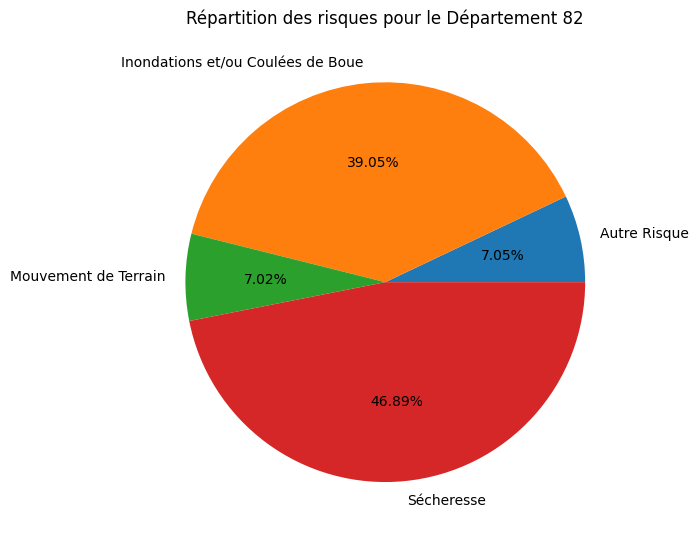

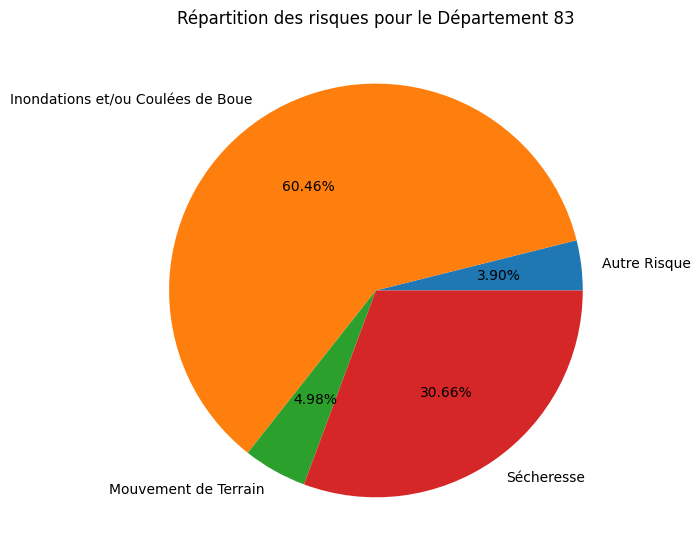

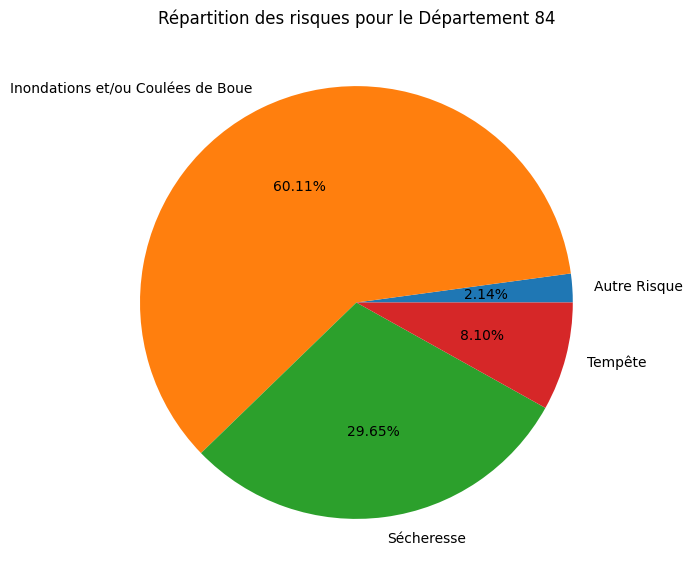

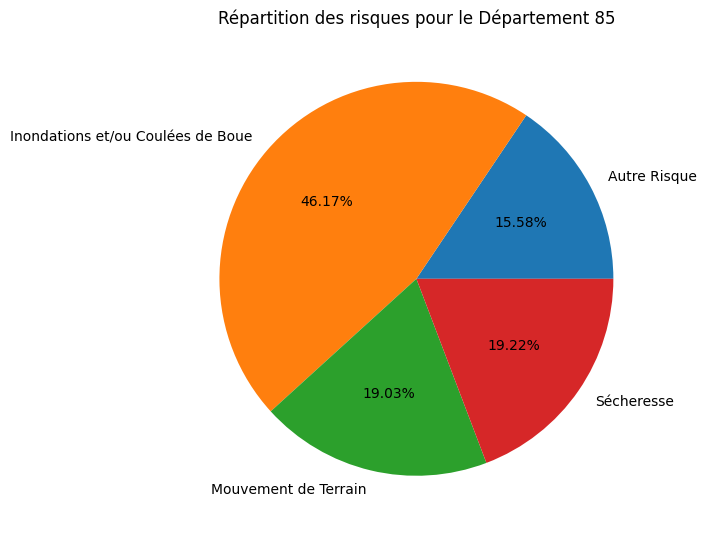

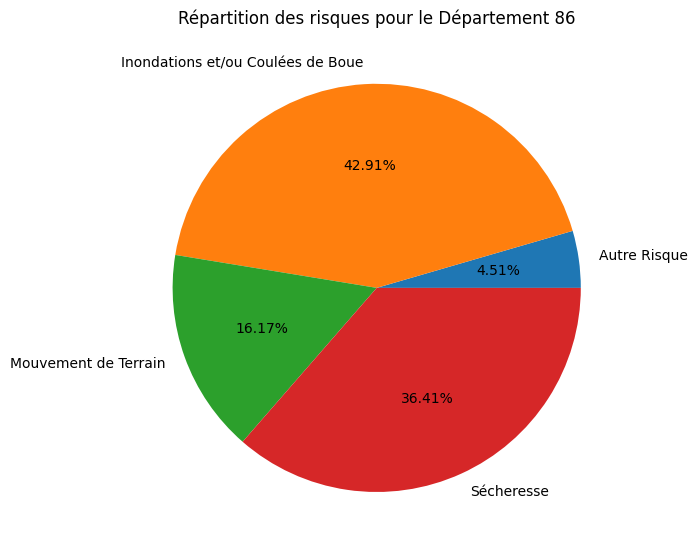

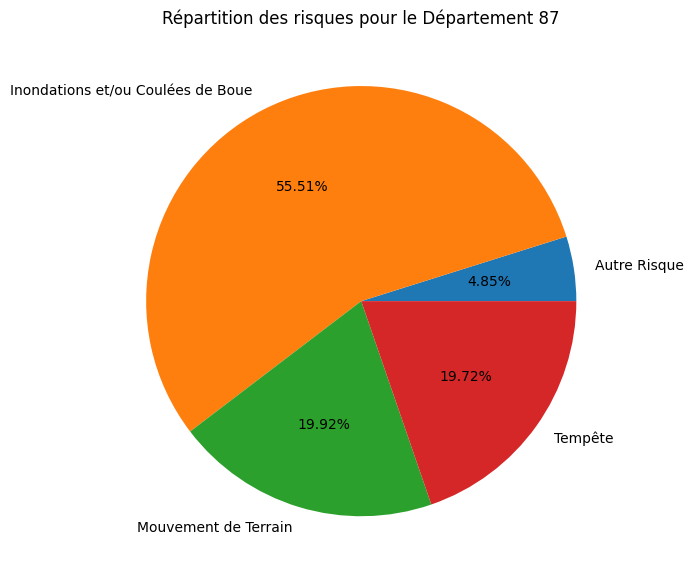

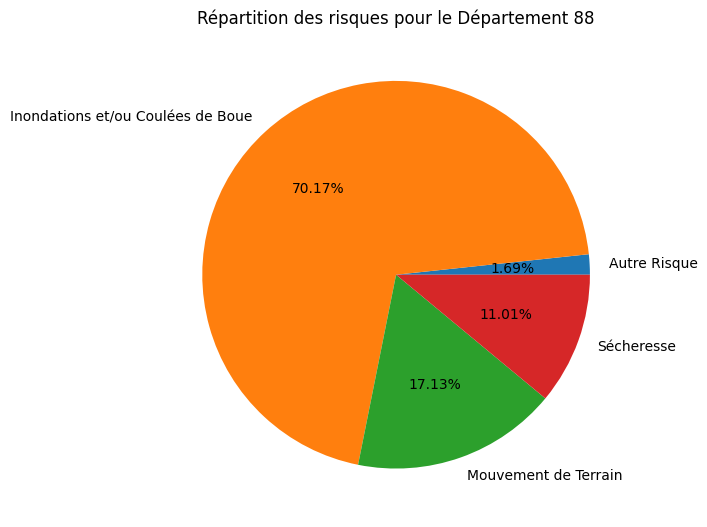

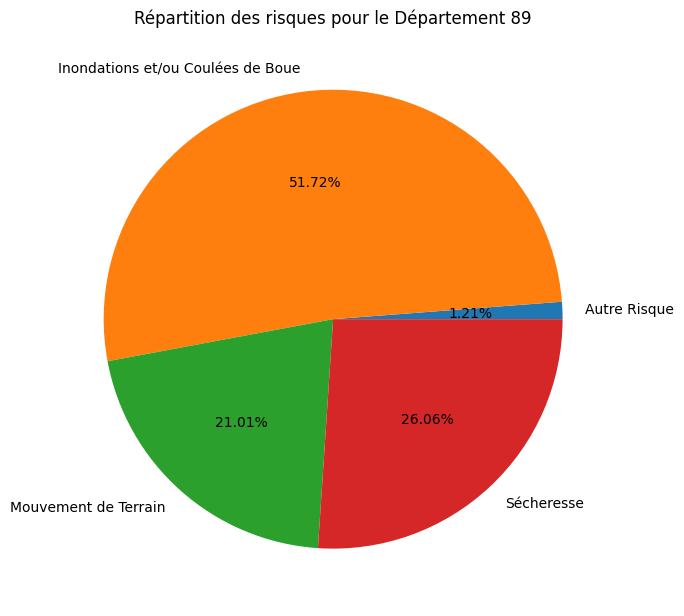

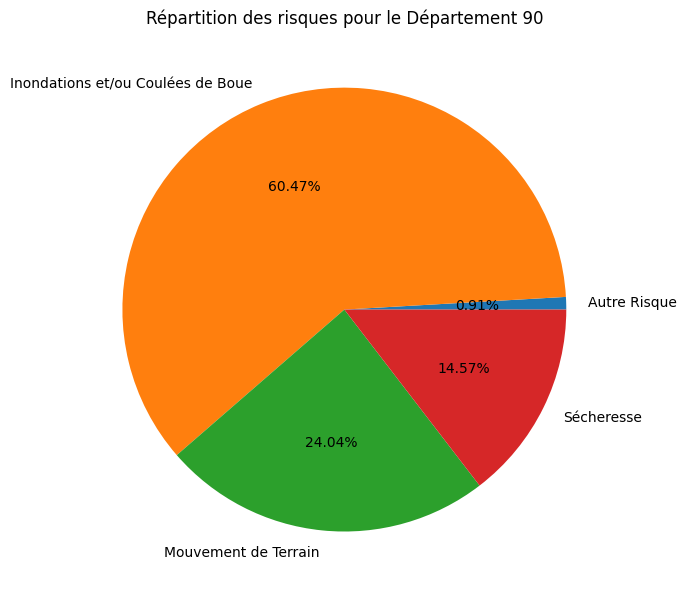

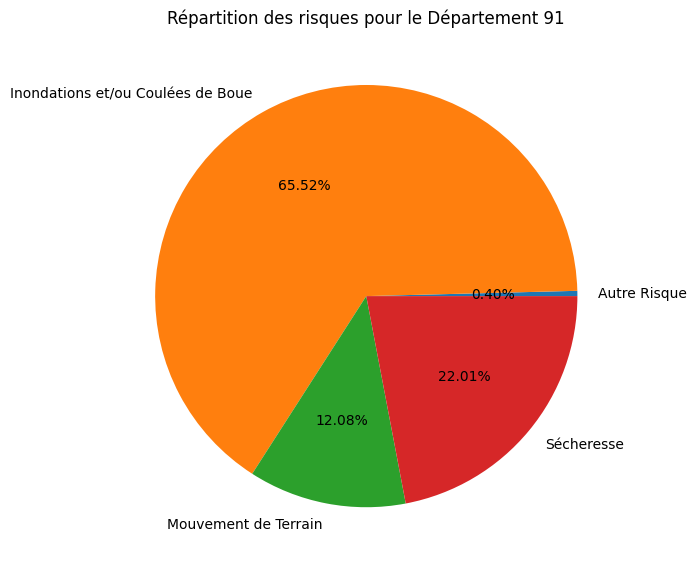

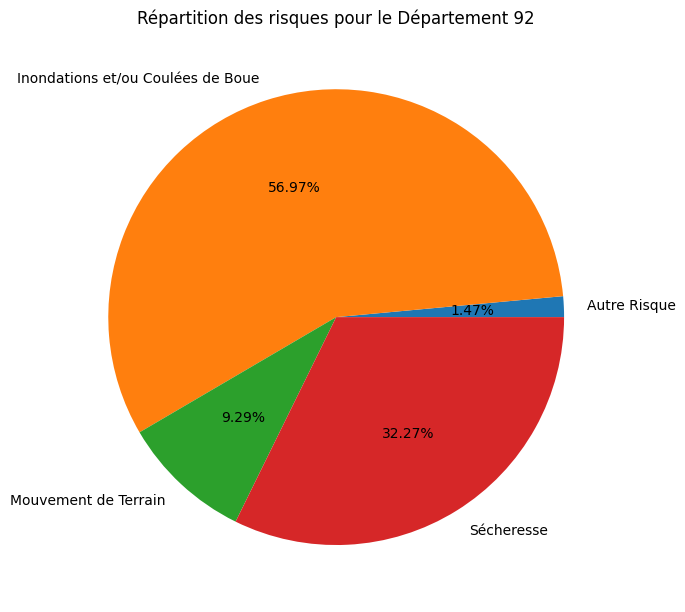

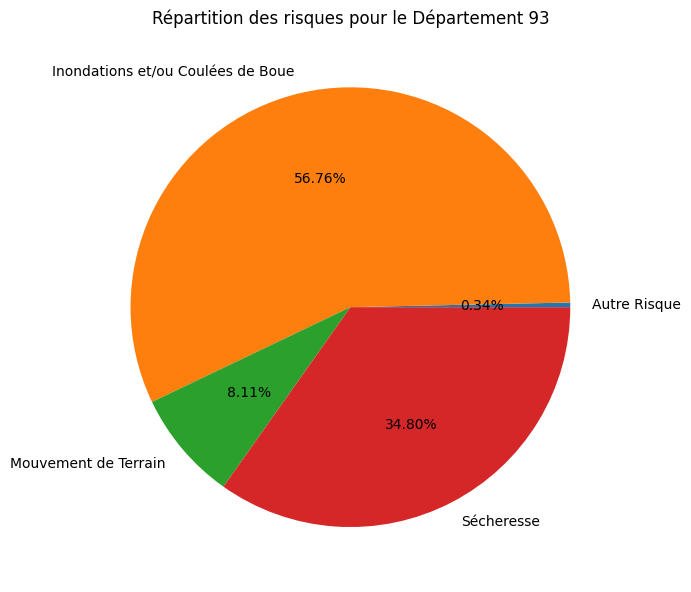

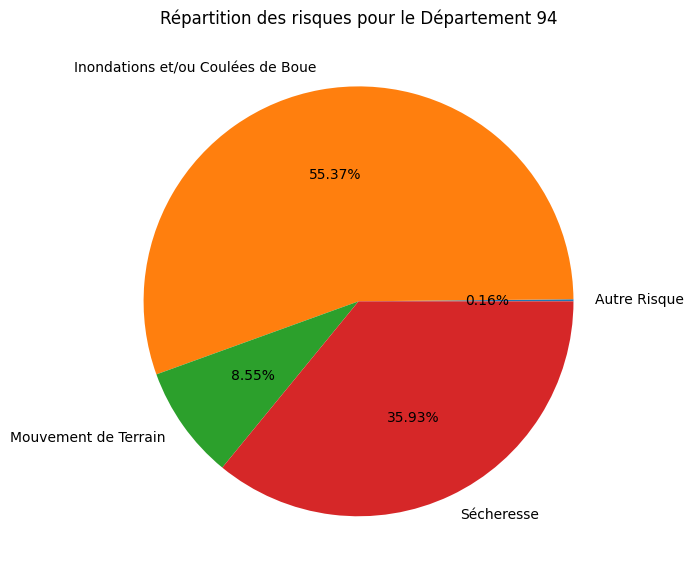

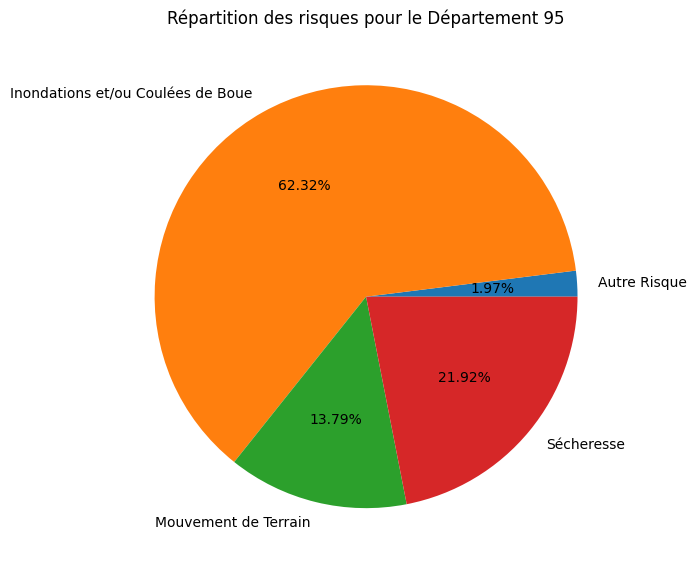

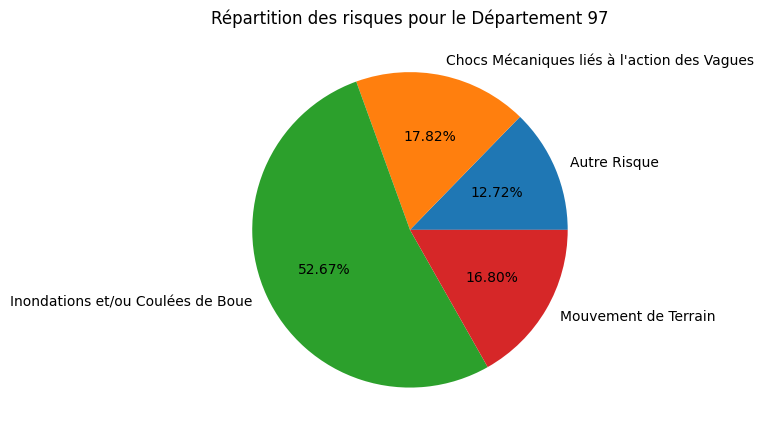

In [13]:
df_plot = (
    df_grouped.groupby(["Département", "lib_risque_grouped"], as_index=False)
      .agg({
          "Total": "sum",
          "SumDpt": "first"
      })
)

df_plot["percent"] = (df_plot["Total"] / df_plot["SumDpt"] * 100).round(2)

for dep in df_plot["Département"].unique():
    df_dep = df_plot[df_plot["Département"] == dep]

    plt.figure(figsize = (7,7))
    plt.pie(
        df_dep["Total"],
        labels=df_dep["lib_risque_grouped"],
        autopct="%1.2f%%",
        
    )
    plt.title(f"Répartition des risques pour le Département {dep}")
    plt.tight_layout()
    plt.show()


#### Hypothèses pour analyses : 

In [14]:
df_grouped["Percent"] = (
    df_grouped["Total"] 
    / df_grouped["SumDpt"] * 100
).round(2)

df_grouped.head()

,Département,lib_risque_jo,Total,SumDpt,rank,lib_risque_grouped,Percent
0,01,Glissement de Terrain,3,1228,6.0,Autre Risque,0.24
1,01,Grêle,7,1228,5.0,Autre Risque,0.57
2,01,Inondations Remontée Nappe,1,1228,7.0,Autre Risque,0.08
3,01,Inondations et/ou Coulées de Boue,776,1228,1.0,Inondations et/ou Coulées de Boue,63.19
4,01,Mouvement de Terrain,51,1228,3.0,Mouvement de Terrain,4.15


A partir de ce *df_grouped*, nous pouvons nous orienter sur des hypothèses d'analyses des Départements avec un double filtre sur le type de CatNat: Son nombre et son taux par rapport aux autres catastrophes subies sur un même département

 - Départements avec des CATNAT de type Inondations et/ou Coulées de Boue > 2500 et dont le taux est > 70%

In [16]:
df_grouped[(df_grouped["lib_risque_jo"] == "Inondations et/ou Coulées de Boue") & (df_grouped["Percent"] > 70) & (df_grouped["Total"] > 2500)]

,Département,lib_risque_jo,Total,SumDpt,rank,lib_risque_grouped,Percent
9,02,Inondations et/ou Coulées de Boue,2812,3850,1.0,Inondations et/ou Coulées de Boue,73.04
435,62,Inondations et/ou Coulées de Boue,4254,6048,1.0,Inondations et/ou Coulées de Boue,70.34
498,70,Inondations et/ou Coulées de Boue,4090,4922,1.0,Inondations et/ou Coulées de Boue,83.10


 - Départements avec un risque de Sécheresse > 40 %

In [17]:
df_grouped[(df_grouped["lib_risque_jo"] == "Sécheresse") & (df_grouped["Percent"] > 40)]

,Département,lib_risque_jo,Total,SumDpt,rank,lib_risque_grouped,Percent
94,13,Sécheresse,923,2105,2.0,Sécheresse,43.85
232,32,Sécheresse,2420,4742,1.0,Sécheresse,51.03
329,45,Sécheresse,886,2086,1.0,Sécheresse,42.47
576,81,Sécheresse,1307,3093,1.0,Sécheresse,42.26
583,82,Sécheresse,1370,2922,1.0,Sécheresse,46.89


<h2 style = "text-align: center; color: green">CatNat Non Reconnues</h2>

### Exploraton des données : 
 - CCR DETAILS => Le nombre de demandes de reconnaissance de catastrophe naturelle **non reconnues** par la commission interministérielle depuis 1982

In [18]:
query = '''
SELECT
	*
FROM dev.main.ccr_details

'''

data = con.sql(query)
df1 = data.df()
df1.head(2)

,codeInsee,nomCommune,dateDebutEvenement,dateFinEvenement,dateArrete,dateParutionJO,nomPeril,franchise,libelleAvis,code_arrete
0,07005,ALBA LA ROMAINE,2025-11-16,2025-11-16,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,-,Non reconnue,904
1,07022,BAIX,2025-11-16,2025-11-17,2026-01-19,2026-01-24,Inondations et/ou Coulées de Boue,Simple,Reconnue,904


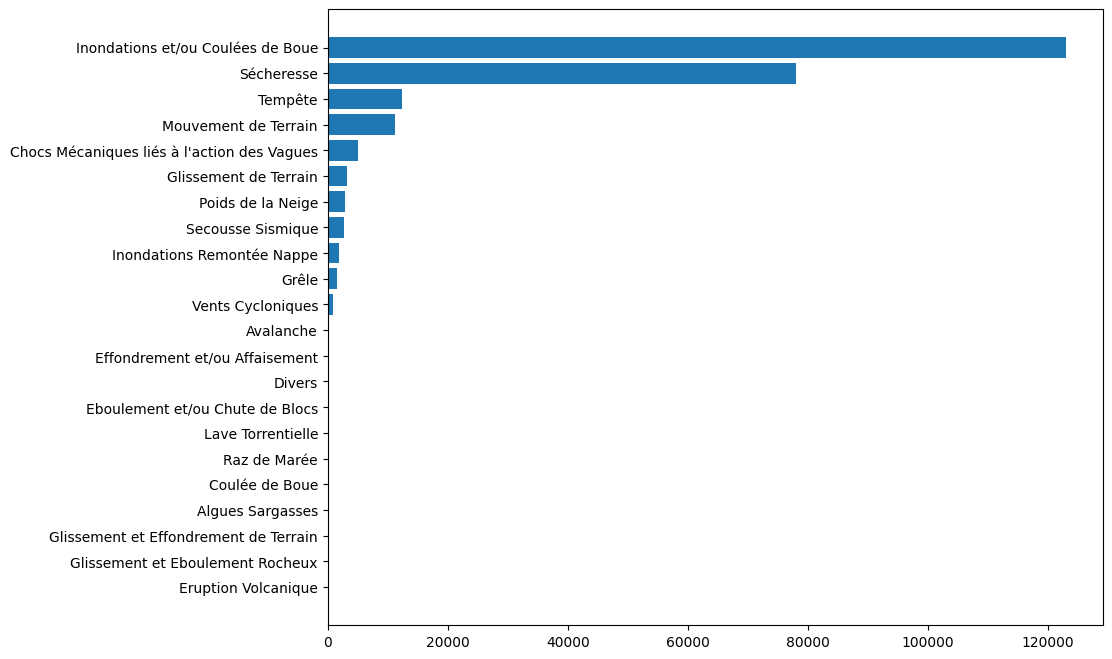

In [19]:
a1 = df1["nomPeril"].value_counts(ascending = True).reset_index(name='count')

plt.figure(figsize = (10,8))
plt.barh(a1["nomPeril"], a1["count"])
plt.xticks()
plt.show()

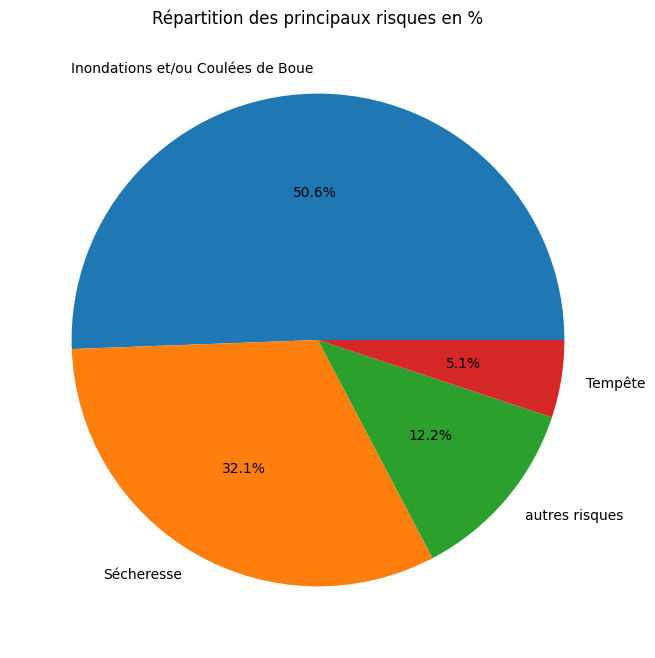

In [20]:
top3a = df1['nomPeril'].value_counts().nlargest(3).index

# Créer une nouvelle colonne "Autres Risques" pour regrouper 
df1['lib_risque_grouped1'] = df1['nomPeril'].where(df1['nomPeril'].isin(top3a),'autres risques')

# Recalculer les volumes
counts1 = df1['lib_risque_grouped1'].value_counts()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(counts1, labels=counts1.index, autopct='%1.1f%%')
plt.title("Répartition des principaux risques en %")
plt.show()